In [ ]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
# from pyspark.sql.functions import last_day, col
from dateutil.relativedelta import relativedelta

from pyspark.sql.functions import create_map
from itertools import chain

from pyspark.sql.functions import to_date, hour, col,count,when,dayofmonth

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [ ]:
fecha_mes_base = '2026-03-01'

query = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.76], '
		SELECT
			uniqueid,
			lead_id,
			user,
			campaign_id,
			call_date,
			status,
			length_in_sec,
			phone_number
		FROM asterisk.vicidial_log
		WHERE DATE(call_date) = ''2026-03-07''      
        and campaign_name like "%SAE"
    ')

    """
df_log=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


query = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.76], '
		SELECT DISTINCT
			a.user,
			a.full_name,
			a.user_group
		FROM asterisk.vicidial_users a
		INNER JOIN asterisk.vicidial_log b
			ON a.user = b.user
		WHERE DATE(b.call_date) = ''2026-03-07''
        and b.campaign_name like "%SAE"
    ')

    """
df_user=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

query = f"""
    SELECT *
		SELECT
			a.user,
			a.campaign_id,
			a.event_time,
			a.wait_sec,
			a.talk_sec,
			a.dispo_sec,
			a.pause_sec,
			a.dead_sec,
			a.status,
			a.lead_id,
			a.uniqueid
		FROM asterisk.vicidial_agent_log a
		INNER JOIN asterisk.vicidial_log b
			ON a.uniqueid = b.uniqueid
		WHERE DATE(b.call_date) = ''2026-03-07''
        and b.campaign_name like "%SAE"
    ')

    """
df_agent=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


In [45]:

query = """
    SELECT 
    ROW_NUMBER() OVER (ORDER BY (SELECT NULL)) AS indice
    ,REGIMEN_LABORAL as regimen_laboral
    ,NOMBRE_1,APELLIDO_PATERNO,APELLIDO_MATERNO
    ,DEPARTAMENTO as last_name
    ,DIRECCION as address2
    ,FEC_FACTURACION as address3
    ,CODDOC as vendor_lead_code
    ,PROVINCIA as province
    ,DISTRITO as city
    ,PRODUCTO as producto
    ,MARCA as marca
    ,TEA as tea
    ,RETIRO
    ,FEC_PAGO,FECHA_ULT_ATM,MONTO_ANT,FECHA_ULT_COMP,MONTO_DESEMBOLSAR,RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC,DISP_RETIRO_EFECT_,MEJORA_TASA,LINEA_SAE,PCT_SAE,ENTIDAD1,DEUDA1,ENTIDAD2,DEUDA2,ENTIDAD3,DEUDA3,EDAD,FRESCURA_TARGET,Segmentacion_Montos,FLG_MEJORA,PROPENSION,TIPDOC
    ,fecha_envio
    FROM ODIN..Base_Maestra_Cencosud_PPFF_Vigente
    """
    
df_base=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

df_base = df_base.withColumn(
    "last_name", 
    F.coalesce(F.col("last_name"), F.lit("Sin_Departamento"))  
)

df_base = df_base.select(
    "*",
    F.coalesce(mapping_expr[F.col("producto")], F.col("producto")).alias("title"),
    F.concat(F.lit("Regimen Lab. "), F.col("regimen_laboral")).alias("first_name"),
    F.concat_ws(
        " ",  
        F.trim(F.coalesce(F.col("APELLIDO_PATERNO"), F.lit(""))),
        F.trim(F.coalesce(F.col("APELLIDO_MATERNO"), F.lit(""))),
        F.trim(F.coalesce(F.col("NOMBRE_1"), F.lit("")))
    ).alias("address1"),
    F.concat_ws(
        " ",  
        F.lit("LINEA SAE "),
        F.col("LINEA_SAE").cast("string")
    ).alias("security_phrase"),
    F.concat(
        F.lit("PCT:"),
        F.coalesce(F.col("PCT_SAE"), F.lit(0)).cast("string"),
        F.lit(" TEA:"),
        F.coalesce(F.col("TEA").cast("double"), F.lit(0.0)).cast("string")
    ).alias("email"),
    F.concat(parte_case, parte_slash).alias("comments")
)

df_base = df_base.withColumn(
    "tipo_base",
    when(dayofmonth(col("fecha_envio")) == 1, "base").otherwise("agregado")
)

df_base = df_base.withColumn(
    "retiro_01",
    col("RETIRO").isNotNull().cast("int")
)




In [ ]:
# print(df_base.columns)
df_base.select('indice', 'regimen_laboral', 'NOMBRE_1', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'last_name', 'address2', 'address3', 'vendor_lead_code', 'province', 'city', 'producto', 'marca', 'tea', 'RETIRO', 'FEC_PAGO', 'FECHA_ULT_ATM', 'MONTO_ANT', 'FECHA_ULT_COMP', 'MONTO_DESEMBOLSAR', 'RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC', 'DISP_RETIRO_EFECT_', 'MEJORA_TASA', 'LINEA_SAE', 'PCT_SAE', 'ENTIDAD1', 'DEUDA1', 'ENTIDAD2', 'DEUDA2', 'ENTIDAD3', 'DEUDA3', 'EDAD', 'FRESCURA_TARGET', 'Segmentacion_Montos', 'FLG_MEJORA', 'PROPENSION', 'TIPDOC', 'fecha_envio', 'title', 'first_name', 'address1', 'security_phrase', 'email', 'comments', 'tipo_base', 'retiro_01').show(5, truncate=False)

+------+---------------+--------+----------------+----------------+----------+---------------------------------------------------------------------------------------+--------+----------------+----------------+-----------------+----------+-----+-----+------+--------+-------------+---------+--------------+-----------------+---------------------------------+------------------+-----------+---------+-------+--------+------+--------+------+--------+------+----+---------------+-------------------+----------+----------+------+-----------+-----+------------------+---------------------+----------------+----------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+---------+
|indice|regimen_laboral|NOMBRE_1|APELLIDO_PATERNO|APELLIDO_MATERNO|last_name |address2                                                                               |address3|vendor_lead_code|province 

In [52]:
import pyspark.sql.functions as F

df_base.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df_base.columns
]).show()

+------+---------------+--------+----------------+----------------+---------+--------+--------+----------------+--------+----+--------+-----+----+------+--------+-------------+---------+--------------+-----------------+---------------------------------+------------------+-----------+---------+-------+--------+------+--------+------+--------+------+----+---------------+-------------------+----------+----------+------+-----------+-----+----------+--------+---------------+-----+--------+---------+---------+
|indice|regimen_laboral|NOMBRE_1|APELLIDO_PATERNO|APELLIDO_MATERNO|last_name|address2|address3|vendor_lead_code|province|city|producto|marca| tea|RETIRO|FEC_PAGO|FECHA_ULT_ATM|MONTO_ANT|FECHA_ULT_COMP|MONTO_DESEMBOLSAR|RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC|DISP_RETIRO_EFECT_|MEJORA_TASA|LINEA_SAE|PCT_SAE|ENTIDAD1|DEUDA1|ENTIDAD2|DEUDA2|ENTIDAD3|DEUDA3|EDAD|FRESCURA_TARGET|Segmentacion_Montos|FLG_MEJORA|PROPENSION|TIPDOC|fecha_envio|title|first_name|address1|security_phrase|email|comments|t

In [ ]:
from pyspark.sql.functions import col

df_base = df_base.withColumn(
    "PROPENSION",
    col("PROPENSION").cast("double")
)

df_base = df_base.withColumn(
    "MONTO_DESEMBOLSAR",
    col("MONTO_DESEMBOLSAR").cast("double")
)

df_base = df_base.withColumn(
    "EDAD",
    col("EDAD").cast("int")
)

In [ ]:
df_base=df_base[[
'indice','tipo_base','regimen_laboral','producto','marca','tea','retiro_01','FEC_PAGO','FECHA_ULT_ATM','MONTO_ANT','FECHA_ULT_COMP','MONTO_DESEMBOLSAR','RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC','DISP_RETIRO_EFECT_','MEJORA_TASA','LINEA_SAE','PCT_SAE','ENTIDAD1','DEUDA1','ENTIDAD2','DEUDA2','ENTIDAD3','DEUDA3','EDAD','FRESCURA_TARGET','Segmentacion_Montos','FLG_MEJORA','PROPENSION','TIPDOC','vendor_lead_code','title','first_name','last_name','address1','address2','address3','city','province','security_phrase','email','comments'
]]

In [20]:
query = f"""
    select FECHA as fecha_gestion,DNI as vendor_lead_code,PROMOTOR as promotor,ESTADO as estado_venta,TRAMA_HORA as tramo_venta,MONTO as monto_venta,DNIEjecutivo as dni_ejecutivo_venta,Producto as producto_venta,Producto as title,Celular as cel_venta from SAMANTHA.dbo.Ventas_Target
    where campana='Cenco_Prest'
    and cast(fecha as date) between '{fecha_mes_base}' and EOMONTH('{fecha_mes_base}')
    """
df_venta=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
query = f"""
    select Telefonos as phone_number,CODDOC as vendor_lead_code,Tipo_Telf as tipo_telf ,Orden as orden_telf from ODIN.dbo.tNumeroCenco_Sae
    """
df_tnumer=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [21]:

df_lista=df_tnumer.join(df_base,['vendor_lead_code'],'left')
df_lista=df_lista.join(df_vicidial,['vendor_lead_code','phone_number'],'left')
df_lista=df_lista.join(df_venta,['vendor_lead_code','title'],'left')
window_spec = Window.partitionBy("indice").orderBy(col("fecha_llamada").desc())
df_lista = df_lista.withColumn("dni_unico", row_number().over(window_spec))
overwrite_table_SQL(spark,df_lista,'borrar_df_cencosud_prestamo',server_sa,user_sa,pwd_sa,'CRONOX')


# listas 

In [ ]:
query = "SELECT * FROM CRONOX.dbo.borrar_df_vicidial"
df_cen=get_data_sql(query, params_sa)
overwrite_table_SQL(spark,df_vicidial,'borrar_df_vicidial',server_sa,user_sa,pwd_sa,'CRONOX')
df_vicidial.to_csv("C:\\Users\\DATA\\Documents\\datos\\01_script\\inicio\\borrar_df_vicidial.csv", index=False)

query = "SELECT * FROM CRONOX.dbo.borrar_df_tnumer"
df_cen=get_data_sql(query, params_sa)
df_tnumer.to_csv("C:\\Users\\DATA\\Documents\\datos\\01_script\\inicio\\borrar_df_tnumer1.csv", index=False)

query = "SELECT * FROM CRONOX.dbo.borrar_df_venta"
df_cen=get_data_sql(query, params_sa)
df_venta.to_csv("C:\\Users\\DATA\\Documents\\datos\\01_script\\inicio\\borrar_df_venta.csv", index=False)

query = "SELECT * FROM CRONOX.dbo.borrar_df_base"
df_cen=get_data_00l(query, params_sa)
df_base.to_csv("C:\\Users\\DATA\\Documents\\datos\\01_script\\inicio\\borrar_df_base.csv", index=False)

In [15]:
overwrite_table_SQL(spark,df_lista,'borrar_df_cencosud_prestamo',server_sa,user_sa,pwd_sa,'CRONOX')

In [12]:

df_lista=df_tnumer.join(df_base,['vendor_lead_code'],'left')
df_lista=df_lista.join(df_vicidial,['vendor_lead_code','phone_number'],'left')
df_lista=df_lista.join(df_venta,['vendor_lead_code','title'],'left')
window_spec = Window.partitionBy("indice").orderBy(col("fecha_llamada").desc())
df_lista = df_lista.withColumn("dni_unico", row_number().over(window_spec))

In [13]:
print(df_lista.columns)

['vendor_lead_code', 'title', 'phone_number', 'tipo_telf', 'orden_telf', 'indice', 'tipo_base', 'regimen_laboral', 'producto', 'marca', 'tea', 'retiro_01', 'FEC_PAGO', 'FECHA_ULT_ATM', 'MONTO_ANT', 'FECHA_ULT_COMP', 'MONTO_DESEMBOLSAR', 'RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC', 'DISP_RETIRO_EFECT_', 'MEJORA_TASA', 'LINEA_SAE', 'PCT_SAE', 'ENTIDAD1', 'DEUDA1', 'ENTIDAD2', 'DEUDA2', 'ENTIDAD3', 'DEUDA3', 'EDAD', 'FRESCURA_TARGET', 'Segmentacion_Montos', 'FLG_MEJORA', 'PROPENSION', 'TIPDOC', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'security_phrase', 'email', 'comments', 'CODIGO', 'numero_campana', 'nombre_campana', 'dni_ejecutivo', 'ejecutivo', 'fecha_hora_llamada', 'duracion', 'descripcion_sn', 'list_description', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'trama', 'COD_TIPO', 'TIPO', 'COD_SUB_DESCRIPCION', 'SUB_DESCRIPCION', 'DESCRIPCION', 'COD_BCO', 'PESO', 'DESC_CODCLI', 'n_mejor_tel', 'mejor_descripcin_telf', 'mejor_fecha_llamad

In [14]:
df_lista.count()

87640

In [ ]:



df_pru=df_lista.filter(df_lista.mejor_descripcin_cli.contains( 'CASILLA'))

In [ ]:
df_lista=df_lista[['vendor_lead_code', 'first_name', 'last_name', 'phone_number', 'title', 'address1', 'address2', 'address3', 'city', 'province', 'tipo_telf', 'orden_telf','email', 'security_phrase', 'comments', 'indice', 'tipo_base', 'regimen_laboral', 'producto', 'marca', 'tea', 'retiro_01', 'FEC_PAGO', 'FECHA_ULT_ATM', 'MONTO_ANT', 'FECHA_ULT_COMP', 'MONTO_DESEMBOLSAR', 'RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC', 'LINEA_SAE', 'PCT_SAE', 'ENTIDAD1', 'DEUDA1', 'ENTIDAD2', 'DEUDA2', 'ENTIDAD3', 'DEUDA3', 'EDAD', 'FRESCURA_TARGET', 'Segmentacion_Montos', 'FLG_MEJORA', 'PROPENSION', 'TIPDOC', 'CODIGO', 'numero_campana', 'nombre_campana', 'dni_ejecutivo', 'ejecutivo', 'fecha_hora_llamada', 'duracion', 'descripcion_sn', 'list_description', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'trama', 'COD_TIPO', 'TIPO', 'COD_SUB_DESCRIPCION', 'SUB_DESCRIPCION', 'DESCRIPCION', 'COD_BCO', 'PESO', 'DESC_CODCLI', 'mejor_descripcin_telf', 'mejor_fecha_llamada_telf', 'mejor_duracion_telf', 'mejor_descripcin_cli', 'mejor_fecha_llamada_cli', 'mejor_duracion_cli', 'ult_descripcin_telf', 'ult_fecha_llamada_telf', 'ult_duracion_telf', 'ult_descripcin_cli', 'ult_fecha_llamada_cli', 'ult_duracion_cli', 'attempt_telf_agent', 'attempt_telf_no_agent', 'attempt_agent', 'attempt_no_agent', 'fecha_gestion', 'promotor', 'estado_venta', 'tramo_venta', 'monto_venta', 'dni_ejecutivo_venta', 'producto_venta', 'cel_venta']]

In [ ]:
window_spec = Window.partitionBy("indice").orderBy(col("fecha_llamada").desc())
df_lista = df_lista.filter(col("dni_unico") == 1).drop('dni_unico')

In [ ]:
df_lista[['LINEA_SAE']].distinct().show()


In [138]:
df_lista[['LINEA_SAE']].distinct().show()

+---------+
|LINEA_SAE|
+---------+
|    38900|
|    28500|
|    14000|
|     3200|
|     6900|
|     2700|
|    33500|
|    28600|
|    34400|
|     1500|
|    27200|
|    13700|
|    34100|
|    17100|
|    11600|
|     2200|
|    22800|
|    31600|
|    27900|
|    15100|
+---------+
only showing top 20 rows


In [ ]:
df = df_lista.withColumn(
    "LINEA_SAE",
    when(col("LINEA_SAE") <= 20, "<=20")
    .when((col("LINEA_SAE") > 20) & (col("LINEA_SAE") <= 30), "20-30")
    .when((col("LINEA_SAE") > 30) & (col("LINEA_SAE") <= 40), "30-40")
    .when((col("LINEA_SAE") > 40) & (col("LINEA_SAE") <= 50), "40-50")
    .when((col("LINEA_SAE") > 50) & (col("LINEA_SAE") <= 60), "50-60")
    .otherwise("60-80")
)

In [ ]:
print(df_base.columns)

In [ ]:
['indice', 'tipo_base', 'regimen_laboral', 'producto', 'marca', 'tea', 'retiro_01', 'FEC_PAGO', 'FECHA_ULT_ATM', 'MONTO_ANT', 'FECHA_ULT_COMP', 'MONTO_DESEMBOLSAR', 'RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC', 'DISP_RETIRO_EFECT_', 'MEJORA_TASA', 'LINEA_SAE', 'PCT_SAE', 'ENTIDAD1', 'DEUDA1', 'ENTIDAD2', 'DEUDA2', 'ENTIDAD3', 'DEUDA3', 'EDAD', 'FRESCURA_TARGET', 'Segmentacion_Montos', 'FLG_MEJORA', 'PROPENSION', 'TIPDOC', 'vendor_lead_code', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'security_phrase', 'email', 'comments']numb

['indice', 'tipo_base', 'regimen_laboral', 'producto', 'marca', 'tea', 'retiro_01', 'FEC_PAGO', 'FECHA_ULT_ATM', 'MONTO_ANT', 'FECHA_ULT_COMP', 'MONTO_DESEMBOLSAR', 'RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC', 'DISP_RETIRO_EFECT_', 'MEJORA_TASA', 'LINEA_SAE', 'PCT_SAE', 'ENTIDAD1', 'DEUDA1', 'ENTIDAD2', 'DEUDA2', 'ENTIDAD3', 'DEUDA3', 'EDAD', 'FRESCURA_TARGET', 'Segmentacion_Montos', 'FLG_MEJORA', 'PROPENSION', 'TIPDOC', 'vendor_lead_code', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'security_phrase', 'email', 'comments']


In [9]:
df_base.filter(col("phone_number") == "958987717").show()

{"ts": "2026-03-06 17:28:19.832", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `phone_number` cannot be resolved. Did you mean one of the following? [`last_name`, `first_name`, `province`, `comments`, `indice`]. SQLSTATE: 42703", "context": {"file": "line 1 in cell [10]", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o617.filter.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `phone_number` cannot be resolved. Did you mean one of the following? [`last_name`, `first_name`, `province`, `comments`, `indice`]. SQLSTATE: 42703;\n'Filter '`=`('phone_number, 958987717)\n+- Project [indice#81L, tipo_base#126, regimen_laboral#82, producto#92, marca#93, tea#94, retiro_01#127, FEC_PAGO#96, F

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `phone_number` cannot be resolved. Did you mean one of the following? [`last_name`, `first_name`, `province`, `comments`, `indice`]. SQLSTATE: 42703;
'Filter '`=`('phone_number, 958987717)
+- Project [indice#81L, tipo_base#126, regimen_laboral#82, producto#92, marca#93, tea#94, retiro_01#127, FEC_PAGO#96, FECHA_ULT_ATM#97, MONTO_ANT#98, FECHA_ULT_COMP#99, MONTO_DESEMBOLSAR#100, RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC#101, DISP_RETIRO_EFECT_#102, MEJORA_TASA#103, LINEA_SAE#104, PCT_SAE#105, ENTIDAD1#106, DEUDA1#107, ENTIDAD2#108, DEUDA2#109, ENTIDAD3#110, DEUDA3#111, EDAD#112, FRESCURA_TARGET#113, ... 16 more fields]
   +- Project [indice#81L, regimen_laboral#82, NOMBRE_1#83, APELLIDO_PATERNO#84, APELLIDO_MATERNO#85, last_name#119, address2#87, address3#88, vendor_lead_code#89, province#90, city#91, producto#92, marca#93, tea#94, RETIRO#95, FEC_PAGO#96, FECHA_ULT_ATM#97, MONTO_ANT#98, FE

In [135]:
df = df_lista.withColumn(
    "rango_tasa",
    when(col("tea") <= 20, "<=20")
    .when((col("tea") > 20) & (col("tea") <= 30), "20-30")
    .when((col("tea") > 30) & (col("tea") <= 40), "30-40")
    .when((col("tea") > 40) & (col("tea") <= 50), "40-50")
    .when((col("tea") > 50) & (col("tea") <= 60), "50-60")
    .otherwise("60-80")
)

from pyspark.sql import functions as F

In [ ]:


df_plot = df.groupBy("rango_tasa").agg(
    F.count(
        F.when(F.col("dni_unico") == 1, 1)
    ).alias("recibidos"),
    F.avg("intentos").alias("intensidad"),
    F.sum("venta").alias("ventas"),
    F.avg("recorrido_flag").alias("recorrido")
)

{"ts": "2026-03-06 16:51:20.579", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `dni_unico` cannot be resolved. Did you mean one of the following? [`indice`, `city`, `dni_ejecutivo`, `ejecutivo`, `email`]. SQLSTATE: 42703", "context": {"file": "line 15 in cell [135]", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o5950.agg.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `dni_unico` cannot be resolved. Did you mean one of the following? [`indice`, `city`, `dni_ejecutivo`, `ejecutivo`, `email`]. SQLSTATE: 42703;\n'Aggregate [rango_tasa#6135], [rango_tasa#6135, 'count(CASE WHEN '`=`('dni_unico, 1) THEN 1 END) AS recibidos#6136, 'avg('intentos) AS intensidad#6137, 'sum('venta) AS venta

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `dni_unico` cannot be resolved. Did you mean one of the following? [`indice`, `city`, `dni_ejecutivo`, `ejecutivo`, `email`]. SQLSTATE: 42703;
'Aggregate [rango_tasa#6135], [rango_tasa#6135, 'count(CASE WHEN '`=`('dni_unico, 1) THEN 1 END) AS recibidos#6136, 'avg('intentos) AS intensidad#6137, 'sum('venta) AS ventas#6138, 'avg('recorrido_flag) AS recorrido#6139]
+- Project [vendor_lead_code#5307, first_name#5289, last_name#5287, phone_number#5306, title#5288, address1#5290, address2#5255, address3#5256, city#5259, province#5258, tipo_telf#5308, orden_telf#5309, email#5292, security_phrase#5291, comments#5293, indice#5249L, tipo_base#5294, regimen_laboral#5250, producto#5260, marca#5261, tea#5262, retiro_01#5295, FEC_PAGO#5264, FECHA_ULT_ATM#5265, MONTO_ANT#5266, ... 68 more fields]
   +- Project [vendor_lead_code#5307, first_name#5289, last_name#5287, phone_number#5306, title#5288

In [ ]:

from pyspark.sql.functions import col

df_plot = df_plot.withColumn(
    "cierre",
    col("ventas") / col("recibidos")
)

In [132]:
query = f"""
select* from MAEBA.[ADM_OBJ_TG].[tGestionMesCencoPP]
where AÑO_DURACION_BASE = '2026'
and MES_DURACION_BASE = '03'
    """
df_01=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

In [133]:
df_01.show()

+--------+---+-----------+--------+--------------------+--------------------+--------------------+--------+-----------------+-----------------+------+----------+------------+---------+---+--------+---------------+------------------+-----------+-------+------------+---------+-------------+------+-------------+--------------+---------+--------+--------+--------+--------+---------+-------------+----+--------------+--------------------+------------------+--------------------+-------+---------------+---------------+-----------------+-----------+-----------+---------+--------+---+--------------+---------+------+---------+---------+-------+-------------+----------+-------------------+------------+----------------+------------------+-----------------+
|  CODDOC|NRG|FECHA_ENVIO|     Dni|        TIPO_GESTION|             GESTION|          SUBGESTION|SERVICIO|AÑO_DURACION_BASE|MES_DURACION_BASE|RETIRO|      TIPO|LINEA_DINERS|RECORRIDO|CET|CONT_GEN|         REGION|      RANGO_OFERTA|    TEA_SEG|  

In [120]:
df_lista.count()

87640

In [125]:
df_lista11=df_lista.filter(df_lista.title == 'REC') \
       .select('PCT_SAE','TEA','vendor_lead_code','email')

In [130]:
df_lista[['DESC_CODCLI']].distinct().show()

+--------------------+
|         DESC_CODCLI|
+--------------------+
|CLIENTE CUELGA AN...|
|NO UTILIZA (TARJE...|
|OFERTA DE TASA MU...|
|NO SE CONCRETO LL...|
|VOLVER A LLAMAR (...|
|ZONA FUERA DE COB...|
|NO VOLVER A LLAMA...|
|TELEFONO OCUPADO ...|
|NO DESEA –NO ESPE...|
| TELEFONO EQUIVOCADO|
|VOLVER A LLAMAR (...|
|    CLIENTE FALLECIO|
|OFERTA DE LINEA M...|
|CLIENTE ACEPTA PR...|
|TELEFONO FUERA DE...|
|DESCONFIA DE GEST...|
|CLIENTE DESEA OTR...|
|REGISTRO NO GESTI...|
|                NULL|
+--------------------+



In [110]:
df_lista01.count()

0

In [ ]:
(df_vicidial.count(), len(df_vicidial.columns))


In [88]:
print(df_lista.columns)

['vendor_lead_code', 'title', 'phone_number', 'tipo_telf', 'orden_telf', 'indice', 'tipo_base', 'regimen_laboral', 'producto', 'marca', 'tea', 'retiro_01', 'FEC_PAGO', 'FECHA_ULT_ATM', 'MONTO_ANT', 'FECHA_ULT_COMP', 'MONTO_DESEMBOLSAR', 'RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC', 'DISP_RETIRO_EFECT_', 'MEJORA_TASA', 'LINEA_SAE', 'PCT_SAE', 'ENTIDAD1', 'DEUDA1', 'ENTIDAD2', 'DEUDA2', 'ENTIDAD3', 'DEUDA3', 'EDAD', 'FRESCURA_TARGET', 'Segmentacion_Montos', 'FLG_MEJORA', 'PROPENSION', 'TIPDOC', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'security_phrase', 'comments', 'CODIGO', 'numero_campana', 'nombre_campana', 'dni_ejecutivo', 'ejecutivo', 'fecha_hora_llamada', 'duracion', 'descripcion_sn', 'list_description', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'trama', 'COD_TIPO', 'TIPO', 'COD_SUB_DESCRIPCION', 'SUB_DESCRIPCION', 'DESCRIPCION', 'COD_BCO', 'PESO', 'DESC_CODCLI', 'n_mejor_tel', 'mejor_descripcin_telf', 'mejor_fecha_llamada_telf', 

In [70]:
(df_lista.count(), len(df_lista.columns))


(87640, 93)

In [103]:
df_base.filter(df_base.title == 'REC') \
       .select('PCT_SAE','TEA','vendor_lead_code','email') \
       .show()

+-------+----+----------------+--------------+
|PCT_SAE| TEA|vendor_lead_code|         email|
+-------+----+----------------+--------------+
|    021|NULL|        00100280|PCT:21 TEA:0.0|
|    035|NULL|        00105122|PCT:35 TEA:0.0|
|    041|NULL|        00115714|PCT:41 TEA:0.0|
|    027|NULL|        00116825|PCT:27 TEA:0.0|
|    022|NULL|        00204566|PCT:22 TEA:0.0|
|    021|NULL|        00208022|PCT:21 TEA:0.0|
|    045|NULL|        00213344|PCT:45 TEA:0.0|
|    022|NULL|        00219760|PCT:22 TEA:0.0|
|    022|NULL|        00225746|PCT:22 TEA:0.0|
|    027|NULL|        00228685|PCT:27 TEA:0.0|
|    032|NULL|        00233609|PCT:32 TEA:0.0|
|    029|NULL|        00245465|PCT:29 TEA:0.0|
|    032|NULL|        00246078|PCT:32 TEA:0.0|
|    037|NULL|        00250479|PCT:37 TEA:0.0|
|    034|NULL|        00251385|PCT:34 TEA:0.0|
|    041|NULL|        00253232|PCT:41 TEA:0.0|
|    028|NULL|        00326463|PCT:28 TEA:0.0|
|    025|NULL|        00327669|PCT:25 TEA:0.0|
|    033|NULL

In [ ]:
PCT_SAE

['CODIGO', 'vendor_lead_code', 'Numero_Campana', 'Nombre_Campana', 'DNI_Ejecutivo', 'Ejecutivo', 'Fecha_Hora_Llamada', 'segundos', 'Descripcion', 'list_description', 'list_name', 'PHONE_NUMBER', 'Fecha_Agenda', 'Comentarios', 'Fecha_Llamada', 'Trama_Hora', 'COD_TIPO', 'TIPO', 'COD_SUB_DESCRIPCION', 'SUB_DESCRIPCION', 'DESCRIPCION', 'COD_BCO', 'PESO', 'DESC_CODCLI', 'mejor_Tel', 'mejor_resul', 'ult_llamada_tel', 'ult_llamada_cli', 'nCant_agent', 'nCant_no_agent', 'q_llamada_cli', 'q_llamada_cli_tel']
['tipo_base', 'REGIMEN_LABORAL', 'producto', 'marca', 'tea', 'retiro_01', 'FEC_PAGO', 'FECHA_ULT_ATM', 'MONTO_ANT', 'FECHA_ULT_COMP', 'MONTO_DESEMBOLSAR', 'RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC', 'DISP_RETIRO_EFECT_', 'MEJORA_TASA', 'LINEA_SAE', 'PCT_SAE', 'ENTIDAD1', 'DEUDA1', 'ENTIDAD2', 'DEUDA2', 'ENTIDAD3', 'DEUDA3', 'EDAD', 'FRESCURA_TARGET', 'Segmentacion_Montos', 'FLG_MEJORA', 'PROPENSION', 'TIPDOC', 'vendor_lead_code', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address

In [ ]:
['CODIGO', 'vendor_lead_code', 'Numero_Campana', 'Nombre_Campana', 'DNI_Ejecutivo', 'Ejecutivo', 'Fecha_Hora_Llamada', 'segundos', 'Descripcion', 'list_description', 'list_name', 'PHONE_NUMBER', 'Fecha_Agenda', 'Comentarios', 'Fecha_Llamada', 'Trama_Hora', 'COD_TIPO', 'TIPO', 'COD_SUB_DESCRIPCION', 'SUB_DESCRIPCION', 'DESCRIPCION', 'COD_BCO', 'PESO', 'DESC_CODCLI', 'mejor_Tel', 'mejor_resul', 'ult_llamada_tel', 'ult_llamada_cli', 'nCant_agent', 'nCant_no_agent', 'q_llamada_cli', 'q_llamada_cli_tel']
['tipo_base', 'REGIMEN_LABORAL', 'producto', 'marca', 'tea', 'retiro_01', 'FEC_PAGO', 'FECHA_ULT_ATM', 'MONTO_ANT', 'FECHA_ULT_COMP', 'MONTO_DESEMBOLSAR', 'RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC', 'DISP_RETIRO_EFECT_', 'MEJORA_TASA', 'LINEA_SAE', 'PCT_SAE', 'ENTIDAD1', 'DEUDA1', 'ENTIDAD2', 'DEUDA2', 'ENTIDAD3', 'DEUDA3', 'EDAD', 'FRESCURA_TARGET', 'Segmentacion_Montos', 'FLG_MEJORA', 'PROPENSION', 'TIPDOC', 'vendor_lead_code', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'security_phrase', 'comments', 'email']numbernu8mber
['fecha_gestion', 'vendor_lead_code', 'promotor', 'estado_venta', 'tramo_venta', 'monto_venta', 'dni_ejecutivo', 'Producto', 'Celular']

email

In [128]:
from pyspark.sql import functions as F

df_b = df_base.filter(F.col("title") == "REC") \
              .select("PCT_SAE","TEA","vendor_lead_code","email")

In [37]:
overwrite_table_SQL(spark,df_b,'borrar_SAr_3',server_sa,user_sa,pwd_sa,'CRONOX')


In [126]:
overwrite_table_SQL(spark,df_lista,'borrar_SAr_00001',server_sa,user_sa,pwd_sa,'CRONOX')


In [129]:
overwrite_table_SQL(spark,df_b,'borrar_SAr_0000ssss00001',server_sa,user_sa,pwd_sa,'CRONOX')


In [46]:
query = "SELECT * FROM CRONOX.dbo.Llave_Cenco_SAE"
df_cenco=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


In [ ]:
columnas_no_actual = [col for col in df_cen_tipif_spark.columns if col not in actual]

print(columnas_no_actual)


{"ts": "2026-03-04 17:06:52.146", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[AMBIGUOUS_REFERENCE] Reference `last_name` is ambiguous, could be: [`last_name`, `last_name`]. SQLSTATE: 42704", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor18.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "AMBIGUOUS_REFERENCE"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o795.select.\n: org.apache.spark.sql.AnalysisException: [AMBIGUOUS_REFERENCE] Reference `last_name` is ambiguous, could be: [`last_name`, `last_name`]. SQLSTATE: 42704\r\n\tat org.apache.spark.sql.errors.QueryCompilationErrors$.ambiguousReferenceError(QueryCompilationErrors.scala:2232)\r\n\tat org.apache.spark.sql.catalyst.expressions.package$AttributeSeq.resolve(package.scala:356)\r\n\tat org.apache.spark.sql.catalyst.plans.logical.LogicalPlan.resolveChildren(LogicalPlan.scala:164)\r\n\tat org.apache.spark.sql.catalyst.analysis.ColumnRe

AnalysisException: [AMBIGUOUS_REFERENCE] Reference `last_name` is ambiguous, could be: [`last_name`, `last_name`]. SQLSTATE: 42704

In [ ]:
columnas_no_actual = [col for col in df_cen_tipif_spark.columns if col not in actual]

print(columnas_no_actual)


In [151]:
df_tmp_llamadas_cencosud.show(5, truncate=False)

+------+--------+--------------+--------------+-------------+------------------+-------------------+--------+----------------------+---------------------------------------+------------------------------+------------+------------+------------------------------------------------------------------------------------------------------------------+-------------+----------+--------+--------------------+-------------------+-----------------------------------------+--------------------------------+-------+----+---------------------------------------+---------+-----------+---------------+---------------+-----------+--------------+-------------+-----------------+
|CODIGO|dni     |Numero_Campana|Nombre_Campana|DNI_Ejecutivo|Ejecutivo         |Fecha_Hora_Llamada |segundos|Descripcion           |list_description                       |list_name                     |PHONE_NUMBER|Fecha_Agenda|Comentarios                                                                                                   

In [152]:
df_tmp_llamadas_cencosud['PRODUCTO'].distinct().show()

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `PRODUCTO` cannot be resolved. Did you mean one of the following? [`CODIGO`, `dni`, `Numero_Campana`, `Nombre_Campana`, `DNI_Ejecutivo`, `Ejecutivo`, `Fecha_Hora_Llamada`, `segundos`, `Descripcion`, `list_description`, `list_name`, `PHONE_NUMBER`, `Fecha_Agenda`, `Comentarios`, `Fecha_Llamada`, `Trama_Hora`, `COD_TIPO`, `TIPO`, `COD_SUB_DESCRIPCION`, `SUB_DESCRIPCION`, `DESCRIPCION`, `COD_BCO`, `PESO`, `DESC_CODCLI`, `mejor_Tel`, `mejor_resul`, `ult_llamada_tel`, `ult_llamada_cli`, `nCant_agent`, `nCant_no_agent`, `q_llamada_cli`, `q_llamada_cli_tel`]. SQLSTATE: 42703

In [104]:
query = "SELECT * FROM CRONOX.dbo.Llave_Cenco_SAE"
df_cen=get_data_sql(query, params_sa)

In [105]:
df_cen.shape

(79410, 63)

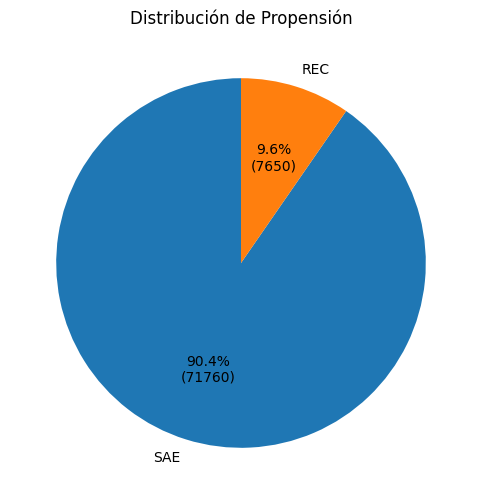

In [106]:
import matplotlib.pyplot as plt

conteo = df_cen["TITLE"].value_counts()

def formato_autopct(pct):
    total = conteo.sum()
    valor = int(round(pct * total / 100.0))
    return f'{pct:.1f}%\n({valor})'

plt.figure(figsize=(6,6))
plt.pie(conteo,
        labels=conteo.index,
        autopct=formato_autopct,
        startangle=90)

plt.title("Distribución de Propensión")
plt.show()

# SAE

In [107]:
df_cen_sae = df_cen[df_cen['TITLE']=='SAE']
df_cen_sar = df_cen[df_cen['TITLE']!='SAE']

In [93]:
df_cen_sae.describe()

,SIN_DISCADOR,LINEA_SAE,LINEA_DESEMBOLSAR,RECORRIDO_HOY,Cantidad_Sin_Discador,Hora_Llamada,Veces_Cliente,Veces_Telefono,REPITENCIAS,Mejor_Fecha_Telefono,Mejor_Duracion_Telefono,Mejor_Fecha_Cliente,Mejor_Duracion_Cliente,Ultimo_Fecha_Telefono,Ultima_Duracion_Telefono,Ultimo_Fecha_Cli,Ultima_Duracion_Cli
count,3748.000000,71718.000000,0.0,71718.000000,3748.000000,57240.000000,57240.000000,19935.000000,7766.000000,71718,71718.000000,71718,71718.000000,71718,71718.000000,71718,71718.000000
mean,1.174760,15195.280125,NaN,0.077205,1.174760,13.421873,2.337788,2.080913,4.412696,1935-01-27 02:40:00.499568,2.005382,2000-09-12 09:45:16.084915,5.814049,1935-01-27 04:39:28.053306,1.761441,2000-09-12 10:52:12.313631,4.434201
min,1.000000,1500.000000,NaN,0.000000,1.000000,8.000000,1.000000,1.000000,0.000000,1900-01-01 00:00:00,0.000000,1900-01-01 00:00:00,0.000000,1900-01-01 00:00:00,0.000000,1900-01-01 00:00:00,0.000000
25%,1.000000,7900.000000,NaN,0.000000,1.000000,11.000000,2.000000,1.000000,2.000000,1900-01-01 00:00:00,0.000000,2026-03-02 11:47:10,0.000000,1900-01-01 00:00:00,0.000000,2026-03-02 12:59:20.750000,0.000000
50%,1.000000,14000.000000,NaN,0.000000,1.000000,14.000000,2.000000,2.000000,5.000000,1900-01-01 00:00:00,0.000000,2026-03-03 09:21:11.500000,0.000000,1900-01-01 00:00:00,0.000000,2026-03-03 09:37:00,0.000000
75%,1.000000,20200.000000,NaN,0.000000,1.000000,16.000000,3.000000,3.000000,6.000000,2026-03-02 10:39:04,0.000000,2026-03-03 12:58:05,0.000000,2026-03-02 14:57:18.500000,0.000000,2026-03-03 14:31:19,0.000000
max,12.000000,40000.000000,NaN,1.000000,12.000000,18.000000,12.000000,12.000000,10.000000,2026-03-03 16:23:50,2482.000000,2026-03-03 16:23:49,2482.000000,2026-03-03 16:23:51,2482.000000,2026-03-03 16:23:51,2482.000000
std,0.581388,10481.631642,NaN,0.266919,0.581388,2.703099,1.084120,0.886124,2.506304,NaN,18.764308,NaN,28.693690,NaN,18.413517,NaN,26.274051


In [94]:
map_prop = {
    "BAJO": 3,
    "MEDIO": 2,
    "ALTO": 1
}

df_cen_sae["propension_score"] = df_cen_sae["PROPENSION"].map(map_prop)

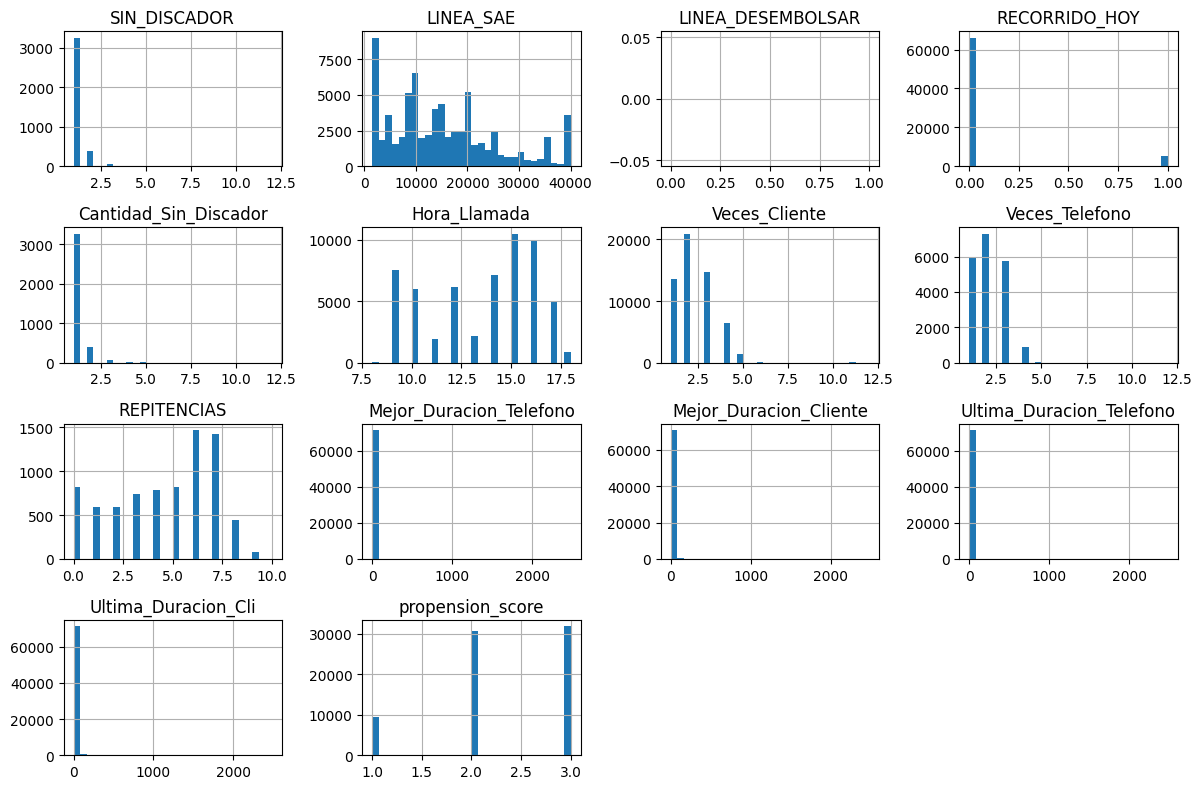

In [95]:
import numpy as np
import matplotlib.pyplot as plt

numeric_cols = df_cen_sae.select_dtypes(include=np.number).columns

df_cen_sae[numeric_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

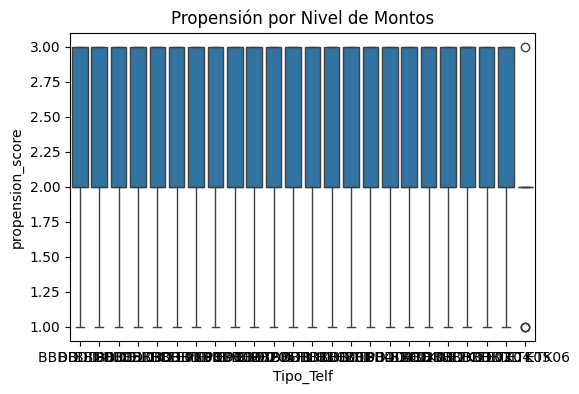

In [68]:

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.boxplot(data=df_cen_sae, x="Tipo_Telf", y="propension_score")
plt.title("Propensión por Nivel de Montos")
plt.show()

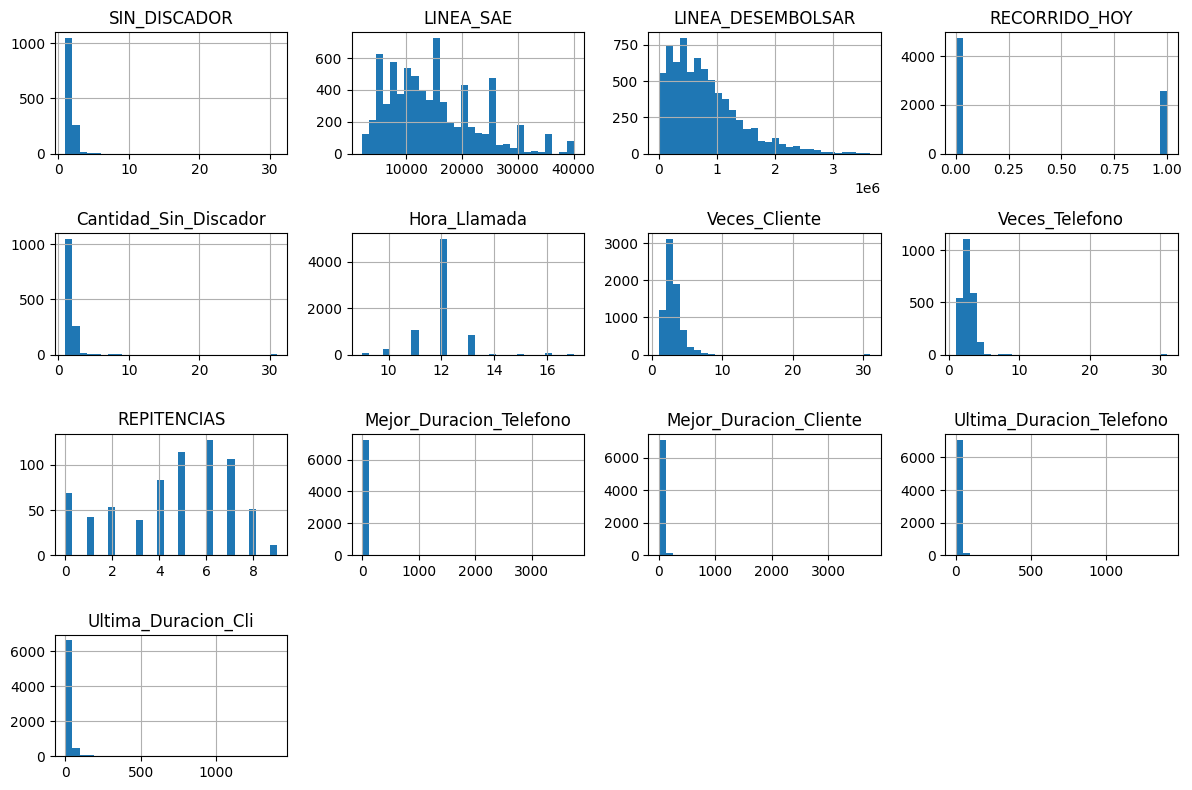

In [42]:
import numpy as np
import matplotlib.pyplot as plt

numeric_cols = df_cen_sar.select_dtypes(include=np.number).columns

df_cen_sar[numeric_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

In [69]:
df_cen_sae.shape

(71629, 64)

In [73]:
df_cen_sae['SIN_DISCADOR'].unique().tolist()

[nan, 1.0, 2.0, 3.0, 5.0, 7.0, 4.0, 6.0, 10.0, 9.0, 8.0]

In [ ]:
df_cen_sae[['PROVEEDOR','Veces_Cliente','Veces_Telefono','Tipo_Telf','LAST NAME','PROPENSION','Segmentacion_Montos','TITLE','MARCA','Hora_Llamada','TEA','LINEA_DESEMBOLSAR','Mejor_Estado_Telefono','Mejor_Descripcion_Telefono']].head()

,PROVEEDOR,Veces_Cliente,Veces_Telefono,Tipo_Telf,LAST NAME,PROPENSION,Segmentacion_Montos,TITLE,MARCA,Hora_Llamada,TEA,LINEA_DESEMBOLSAR,Mejor_Estado_Telefono,Mejor_Descripcion_Telefono
0,WEB,3.0,NaN,BBDD EIP01,LIMA,BAJO,20000 a 24999,SAE,Y,12.0,0.149,NaN,NO CARGADO,1.SIN GESTION
1,WEB,3.0,NaN,BBDD EIP01,LIMA,BAJO,20000 a 24999,SAE,Y,12.0,0.149,NaN,NO CARGADO,1.SIN GESTION
2,NaN,3.0,NaN,BBDD HU05,LIMA,BAJO,20000 a 24999,SAE,Y,12.0,0.149,NaN,NO CARGADO,1.SIN GESTION
3,BCO,NaN,NaN,BBDD CEL03,LIMA,BAJO,5000 a 9999,SAE,N,NaN,0.549,NaN,NO CARGADO,1.SIN GESTION
4,WEB,NaN,NaN,BBDD EIP03,LIMA,BAJO,5000 a 9999,SAE,N,NaN,0.549,NaN,NO CARGADO,1.SIN GESTION


In [75]:
df_cen_sae["Tipo_Telf"].value_counts()

Tipo_Telf
BBDD CEL01    23797
BBDD EIP01    16536
BBDD EIP02     8588
BBDD EIP03     5416
BBDD EIP04     3366
BBDD EIP05     2259
BBDD EPC02     1925
BBDD EPC03     1614
BBDD EPC01     1446
BBDD INT1      1387
BBDD HU02       844
BBDD HU01       837
BBDD HU03       760
BBDD HU04       614
BBDD CEL03      472
BBDD ETK01      454
BBDD HU05       408
BBDD ETK02      251
BBDD CEL02      242
BBDD INT2       185
BBDD ETK03      124
BBDD ETK04       61
BBDD ETK05       30
BBDD ETK06       13
Name: count, dtype: int64

In [ ]:
df_cen_sae['Tipo_Telf'].unique()

<StringArray>
['BBDD EIP01',  'BBDD HU05', 'BBDD CEL03', 'BBDD EIP03', 'BBDD CEL01',
 'BBDD EPC01', 'BBDD EPC03', 'BBDD EPC02', 'BBDD EIP02', 'BBDD EIP05',
  'BBDD INT1',  'BBDD HU03',  'BBDD HU02',  'BBDD HU01', 'BBDD EIP04',
  'BBDD HU04', 'BBDD ETK02', 'BBDD ETK03',  'BBDD INT2', 'BBDD ETK01',
 'BBDD CEL02', 'BBDD ETK04', 'BBDD ETK05', 'BBDD ETK06']
Length: 24, dtype: str

In [43]:
df_cen[df_cen['LINEA_DESEMBOLSAR'].notna()][['PROVEEDOR','Veces_Cliente','Veces_Telefono','Tipo_Telf','LAST NAME','PROPENSION','Segmentacion_Montos','TITLE','MARCA','Hora_Llamada','TEA','LINEA_DESEMBOLSAR','Mejor_Estado_Telefono','Mejor_Descripcion_Telefono']].count()

PROVEEDOR                     6974
Veces_Cliente                 7310
Veces_Telefono                2379
Tipo_Telf                     7310
LAST NAME                     7310
PROPENSION                    7310
Segmentacion_Montos           7310
TITLE                         7310
MARCA                         7310
Hora_Llamada                  7310
TEA                           7310
LINEA_DESEMBOLSAR             7310
Mejor_Estado_Telefono         7310
Mejor_Descripcion_Telefono    7310
dtype: int64

In [34]:
df_uno=pd.read_excel("C:\\Users\\DATA\\Documents\\datos\\01_script\\inicio\\alto_medio_cencosud_03032026.xlsx")


In [ ]:
['TITLE', 'FIRST NAME', '', 'ADDRESS1', 'Address2', 'Address3', 'COMMENTS', 'SECURITY PHRASE', 'EMAIL', 'COMMENTS_CD', 'VENDOR LEAD CODE', 'PROVINCE', 'CITY', 'PHONE NUMBER', 'PRODUCTO', 'SIN_DISCADOR', 'FEC_FACTURACION', 'MARCA', '', 'TIP_TELF', 'PROVEEDOR', 'TEA_SEG', 'RANGO_EDAD', 'REGIMEN_LABORAL', 'EDAD', 'LINEA_SAE', 'LINEA_DESEMBOLSAR', '', 'PROPENSION', 'Frescura', 'RECORRIDO_HOY', 'Antiguedad', 'Antiguedad2', 'Antiguedad3', 'Cantidad_Sin_Discador', 'BURNED', 'Fecha_Llam', '', 'FECHA_ENVIO', '', '', '', 'RANGO_VECES_TELEFONOS', 'REPITENCIAS', 'Mejor_Estado_Telefono', 'Mejor_Sub_Estado_Telefono', 'Mejor_Descripcion_Telefono', 'Mejor_Fecha_Telefono', 'Mejor_Duracion_Telefono', 'Mejor_Estado_Cliente', 'Mejor_Sub_Estado_Cliente', 'Mejor_Descripcion_Cliente', 'Mejor_Fecha_Cliente', 'Mejor_Duracion_Cliente', 'Ultimo_Descripcion_Telefono', 'Ultimo_Fecha_Telefono', 'Ultima_Duracion_Telefono', 'Ultimo_Descripcion_Cli', 'Ultimo_Fecha_Cli', 'Ultima_Duracion_Cli', 'DNI_Ejecutivo', 'Codigo_Paleta', 'flg_mejora']

df_cen[['PROVEEDOR','Veces_Cliente','Veces_Telefono','Tipo_Telf','LAST NAME','PROPENSION','Segmentacion_Montos','TITLE','MARCA','Hora_Llamada','TEA','LINEA_DESEMBOLSAR','Mejor_Estado_Telefono','Mejor_Descripcion_Telefono']]

['TITLE', 'FIRST NAME', 'LAST NAME', 'ADDRESS1', 'Address2', 'Address3', 'COMMENTS', 'SECURITY PHRASE', 'EMAIL', 'COMMENTS_CD', 'VENDOR LEAD CODE', 'PROVINCE', 'CITY', 'PHONE NUMBER', 'PRODUCTO', 'SIN_DISCADOR', 'FEC_FACTURACION', 'MARCA', 'TEA', 'TIP_TELF', 'PROVEEDOR', 'TEA_SEG', 'RANGO_EDAD', 'REGIMEN_LABORAL', 'EDAD', 'LINEA_SAE', 'LINEA_DESEMBOLSAR', 'Segmentacion_Montos', 'PROPENSION', 'Frescura', 'RECORRIDO_HOY', 'Antiguedad', 'Antiguedad2', 'Antiguedad3', 'Cantidad_Sin_Discador', 'BURNED', 'Fecha_Llam', 'Hora_Llamada', 'FECHA_ENVIO', 'Tipo_Telf', 'Veces_Cliente', 'Veces_Telefono', 'RANGO_VECES_TELEFONOS', 'REPITENCIAS', 'Mejor_Estado_Telefono', 'Mejor_Sub_Estado_Telefono', 'Mejor_Descripcion_Telefono', 'Mejor_Fecha_Telefono', 'Mejor_Duracion_Telefono', 'Mejor_Estado_Cliente', 'Mejor_Sub_Estado_Cliente', 'Mejor_Descripcion_Cliente', 'Mejor_Fecha_Cliente', 'Mejor_Duracion_Cliente', 'Ultimo_Descripcion_Telefono', 'Ultimo_Fecha_Telefono', 'Ultima_Duracion_Telefono', 'Ultimo_Descrip

In [ ]:
df_uno[['PROVEEDOR','Veces_Cliente','Veces_Telefono','Tipo_Telf','LAST NAME','PROPENSION','Segmentacion_Montos','TITLE','MARCA','Hora_Llamada','TEA']].head()


,PROVEEDOR,Veces_Cliente,Veces_Telefono,Tipo_Telf,LAST NAME,PROPENSION,Segmentacion_Montos,TITLE,MARCA,Hora_Llamada,TEA
0,BCO,NaN,NaN,BBDD CEL01,LIMA,BAJO,10000 a 14999,SAE,N,NaN,0.519
1,BCO,NaN,NaN,BBDD CEL01,CALLAO,BAJO,20000 a 24999,SAE,Y,NaN,0.149
2,BCO,NaN,NaN,BBDD CEL01,AREQUIPA,BAJO,10000 a 14999,SAE,N,NaN,0.529
3,BCO,NaN,NaN,BBDD CEL01,LIMA,BAJO,15000 a 19999,SAE,N,NaN,0.499
4,BCO,NaN,NaN,BBDD CEL01,LIMA,BAJO,20000 a 24999,SAE,N,NaN,0.229


C:\Users\DATA\AppData\Local\Temp\ipykernel_3292\3323899469.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(conteo.index, rotation=45, ha="right")


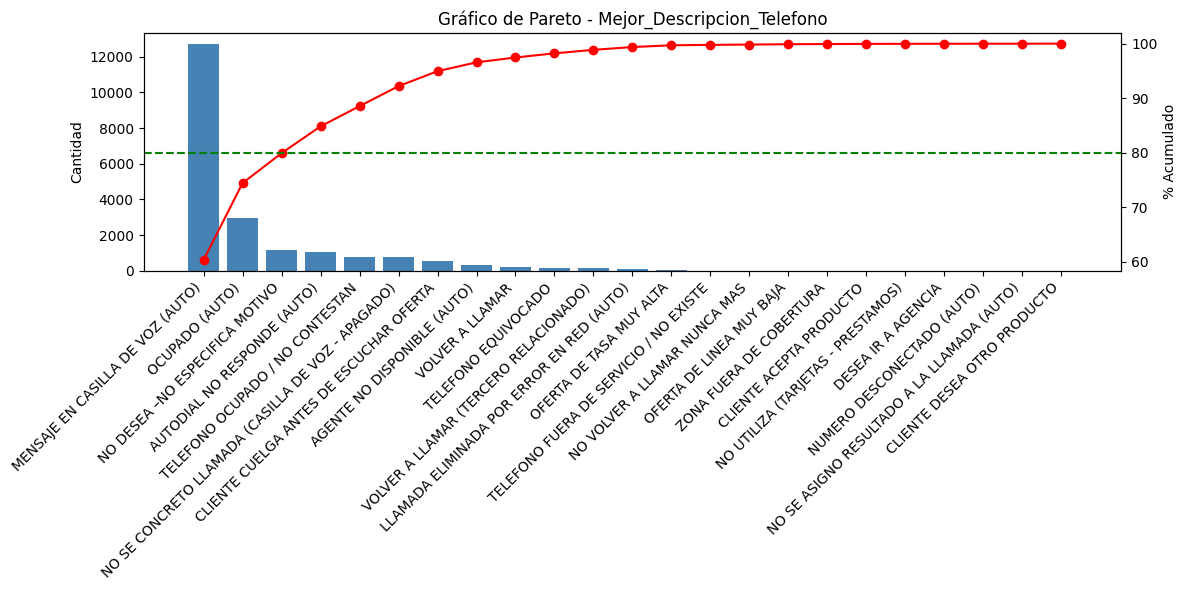

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# Conteo ordenado
conteo = df_cen_sae[~df_cen_sae["Mejor_Descripcion_Telefono"].str.contains('SIN GESTION')]["Mejor_Descripcion_Telefono"].value_counts().sort_values(ascending=False)





# Porcentaje acumulado
porc_acum = conteo.cumsum() / conteo.sum() * 100

fig, ax1 = plt.subplots(figsize=(12,6))

# Barras
ax1.bar(conteo.index, conteo.values, color="steelblue")
ax1.set_ylabel("Cantidad")
ax1.set_xticklabels(conteo.index, rotation=45, ha="right")

# Línea acumulada
ax2 = ax1.twinx()
ax2.plot(conteo.index, porc_acum, color="red", marker="o")
ax2.set_ylabel("% Acumulado")

# Línea 80%
ax2.axhline(80, color="green", linestyle="--")

plt.title("Gráfico de Pareto - Mejor_Descripcion_Telefono")
plt.tight_layout()
plt.show()

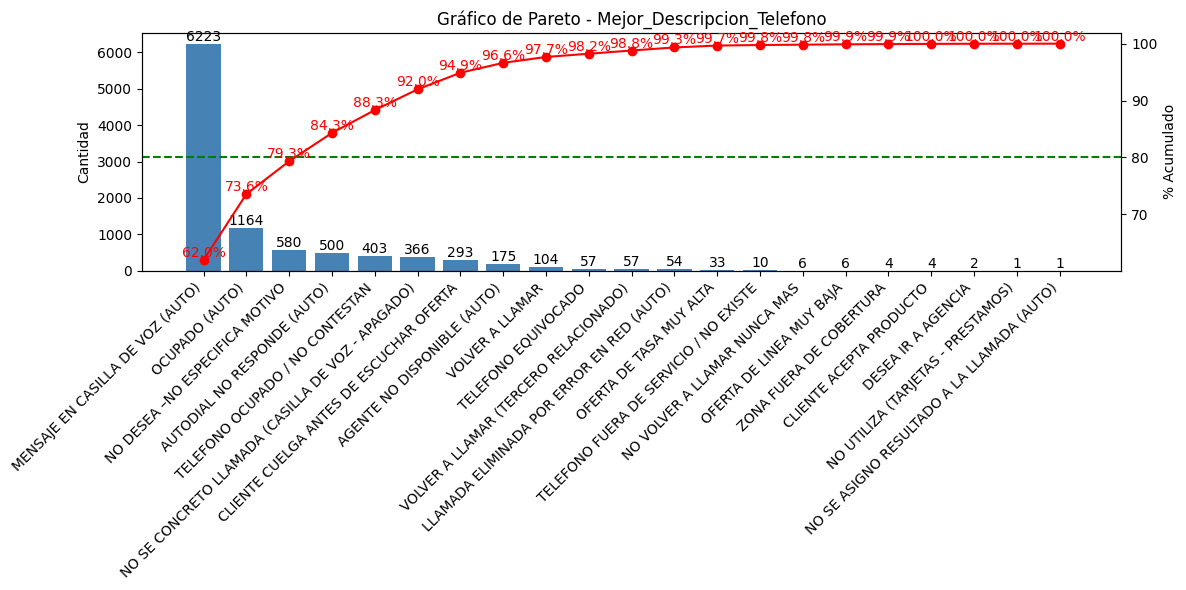

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar SIN GESTION
# df_filtrado = df_cen_sae[
#     ~df_cen_sae["Mejor_Descripcion_Telefono"].str.contains("SIN GESTION", na=False)
# ]
df_filtrado = df_cen_sae[
    (~df_cen_sae["Mejor_Descripcion_Telefono"].str.contains("SIN GESTION", na=False)) &
    (df_cen_sae["Tipo_Telf"].isin(['BBDD CEL01','BBDD CEL03','BBDD CEL02']))&
    (df_cen_sae["PROPENSION"].isin(['ALTO','BAJO']))
]

# Conteo ordenado
conteo = df_filtrado["Mejor_Descripcion_Telefono"] \
            .value_counts() \
            .sort_values(ascending=False)

# % acumulado
porc_acum = conteo.cumsum() / conteo.sum() * 100

fig, ax1 = plt.subplots(figsize=(12,6))

# 🔵 Barras
bars = ax1.bar(conteo.index, conteo.values, color="steelblue")
ax1.set_ylabel("Cantidad")

# 👉 Etiquetas de cantidad en barras
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha="right")

# 🔴 Línea acumulada
ax2 = ax1.twinx()
ax2.plot(conteo.index, porc_acum, color="red", marker="o")
ax2.set_ylabel("% Acumulado")

# 👉 Etiquetas de % acumulado
for i, txt in enumerate(porc_acum):
    ax2.text(i, txt, f"{txt:.1f}%", color="red", ha="center", va="bottom")

# Línea 80%
ax2.axhline(80, color="green", linestyle="--")

plt.title("Gráfico de Pareto - Mejor_Descripcion_Telefono")
plt.tight_layout()
plt.show()

In [87]:
corte_80 = porc_acum[porc_acum <= 80].index.tolist()
print("Categorías que explican el 80%:", corte_80)

Categorías que explican el 80%: ['MENSAJE EN CASILLA DE VOZ (AUTO)', 'OCUPADO (AUTO)']


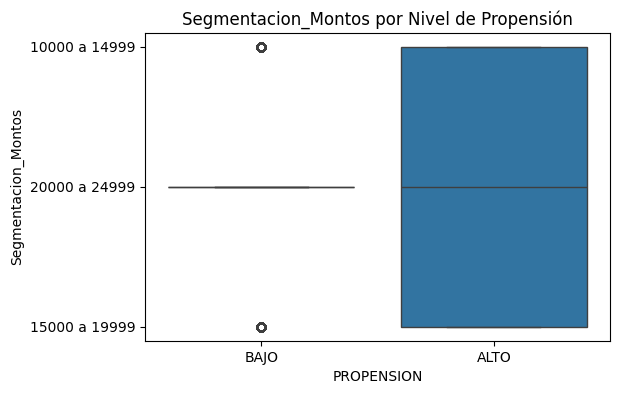

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_uno, x="PROPENSION", y="Segmentacion_Montos")
plt.title("Segmentacion_Montos por Nivel de Propensión")
plt.show()

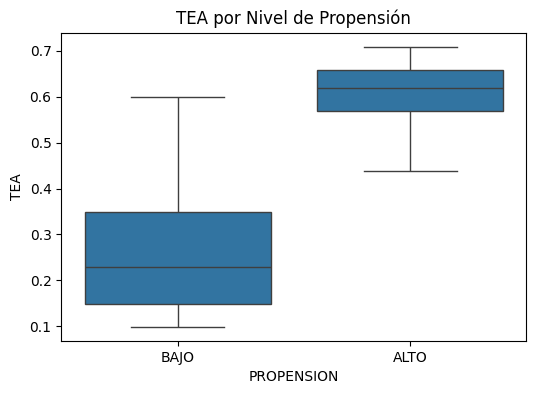

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_uno, x="PROPENSION", y="TEA")
plt.title("TEA por Nivel de Propensión")
plt.show()

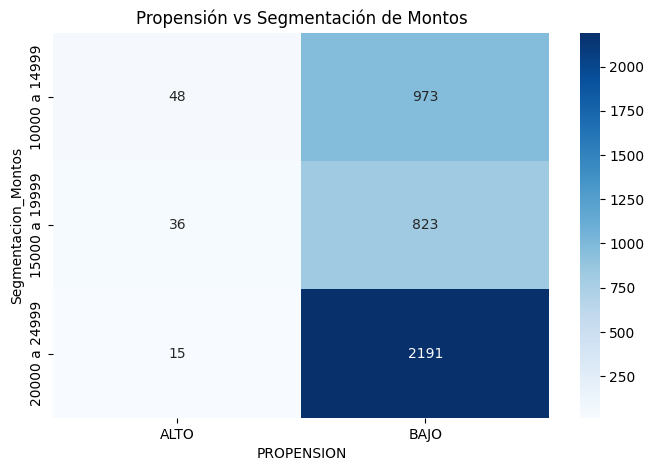

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tabla = pd.crosstab(df_uno["Segmentacion_Montos"], df_uno["PROPENSION"])

plt.figure(figsize=(8,5))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
plt.title("Propensión vs Segmentación de Montos")
plt.show()

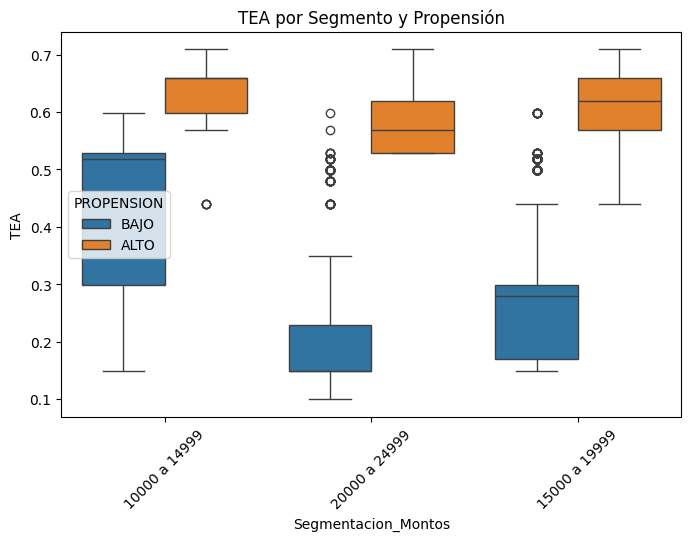

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_uno, x="Segmentacion_Montos", y="TEA", hue="PROPENSION")
plt.xticks(rotation=45)
plt.title("TEA por Segmento y Propensión")
plt.show()

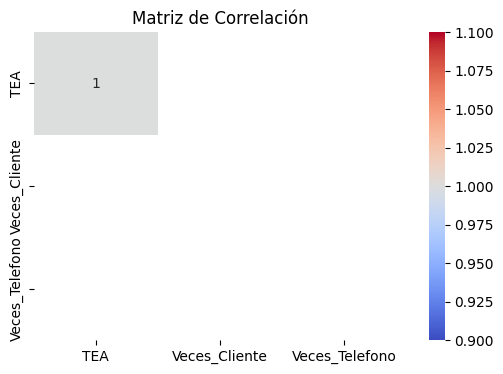

In [53]:
corr = df_uno[["TEA","Veces_Cliente","Veces_Telefono"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

In [52]:
df_uno[['PROVEEDOR','Veces_Cliente','Veces_Telefono','Tipo_Telf','LAST NAME','PROPENSION','Segmentacion_Montos','TITLE','MARCA','Hora_Llamada','TEA']].describe()


,Veces_Cliente,Veces_Telefono,Hora_Llamada,TEA
count,3219.0,3191.0,3219.000000,4086.000000
mean,1.0,1.0,11.724138,0.278256
std,0.0,0.0,1.601646,0.162232
min,1.0,1.0,9.000000,0.099000
25%,1.0,1.0,11.000000,0.149000
50%,1.0,1.0,12.000000,0.229000
75%,1.0,1.0,13.000000,0.499000
max,1.0,1.0,16.000000,0.709000


In [ ]:
df_uno[['PROVEEDOR','Veces_Cliente','Veces_Telefono','Tipo_Telf','LAST NAME','PROPENSION','Segmentacion_Montos','TITLE','MARCA','Hora_Llamada','TEA']].head()
Mejor_Descripcion_Telefono

In [51]:
df_uno.describe()

,Address3,VENDOR LEAD CODE,PHONE NUMBER,SIN_DISCADOR,FEC_FACTURACION,TEA,EDAD,LINEA_SAE,LINEA_DESEMBOLSAR,Frescura,...,Cantidad_Sin_Discador,BURNED,Hora_Llamada,Veces_Cliente,Veces_Telefono,REPITENCIAS,Mejor_Duracion_Telefono,Mejor_Duracion_Cliente,Ultima_Duracion_Telefono,Ultima_Duracion_Cli
count,4086.000000,4.086000e+03,4.086000e+03,158.0,4086.000000,4086.000000,4086.000000,4086.000000,0.0,4086.000000,...,158.0,0.0,3219.000000,3219.0,3191.0,569.000000,4086.000000,4086.000000,4086.000000,4086.000000
mean,12.054821,2.204080e+07,9.710442e+08,1.0,12.054821,0.278256,56.347283,21699.583945,NaN,0.510279,...,1.0,NaN,11.724138,1.0,1.0,4.831283,0.752814,0.773128,0.752814,0.773128
std,5.666706,1.665567e+07,2.346631e+07,0.0,5.666706,0.162232,11.909596,9013.306215,NaN,0.499956,...,0.0,NaN,1.601646,0.0,0.0,2.236778,5.331469,5.377288,5.331469,5.377288
min,6.000000,7.011100e+04,9.006337e+08,1.0,6.000000,0.099000,27.000000,10000.000000,NaN,0.000000,...,1.0,NaN,9.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,8.446051e+06,9.528735e+08,1.0,7.000000,0.149000,48.000000,15000.000000,NaN,0.000000,...,1.0,NaN,11.000000,1.0,1.0,3.000000,0.000000,0.000000,0.000000,0.000000
50%,10.000000,1.575430e+07,9.766857e+08,1.0,10.000000,0.229000,56.000000,20000.000000,NaN,1.000000,...,1.0,NaN,12.000000,1.0,1.0,5.000000,0.000000,0.000000,0.000000,0.000000
75%,20.000000,4.019524e+07,9.922696e+08,1.0,20.000000,0.499000,66.000000,26400.000000,NaN,1.000000,...,1.0,NaN,13.000000,1.0,1.0,7.000000,0.000000,0.000000,0.000000,0.000000
max,25.000000,8.065386e+07,9.999989e+08,1.0,25.000000,0.709000,80.000000,40000.000000,NaN,1.000000,...,1.0,NaN,16.000000,1.0,1.0,9.000000,216.000000,216.000000,216.000000,216.000000


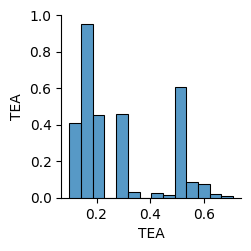

In [50]:
sns.pairplot(df_uno[["PROPENSION","Segmentacion_Montos","TEA"]])
plt.show()

In [35]:
df_uno.head()

,TITLE,FIRST NAME,LAST NAME,ADDRESS1,Address2,Address3,COMMENTS,SECURITY PHRASE,EMAIL,COMMENTS_CD,...,Mejor_Duracion_Cliente,Ultimo_Descripcion_Telefono,Ultimo_Fecha_Telefono,Ultima_Duracion_Telefono,Ultimo_Descripcion_Cli,Ultimo_Fecha_Cli,Ultima_Duracion_Cli,DNI_Ejecutivo,Codigo_Paleta,flg_mejora
0,SAE,Regimen Lab. INFOR,LIMA,MAITA HOYOS MARGARITA,AVENIDA LOS JAZMINES SN URBANIZACION SN MZ.E1 ...,10,DEUDA_ACTUAL Sin Fecha MONTO_DESEMBOLSAR Sin M...,LINEA SAE 10000,PCT: 038 TEA: 0.519,//CONSENTIMIENTO:N//ENTIDAD1://DEUDA1://ENTIDA...,...,0,1.SIN GESTION,1900-01-01 00:00:00.0000000,0,1.SIN GESTION,1900-01-01 00:00:00.0000000,0,NaN,NaN,NaN
1,SAE,Regimen Lab. INDEP,CALLAO,RAMIREZ DIAZ ANGIE,JIRON PACIFICO VILLA SEÑOR DE LOS MILAGROS 584...,20,DEUDA_ACTUAL Sin Fecha MONTO_DESEMBOLSAR Sin M...,LINEA SAE 22600,PCT: 018 TEA: 0.149,//CONSENTIMIENTO:Y//ENTIDAD1://DEUDA1://ENTIDA...,...,0,1.SIN GESTION,1900-01-01 00:00:00.0000000,0,1.SIN GESTION,1900-01-01 00:00:00.0000000,0,NaN,NaN,NaN
2,SAE,Regimen Lab. INFOR,AREQUIPA,TRIVEÑO LUQUE ANDRE,AVENIDA SN QUINTA RESIDENCIAL CAYMA URBANIZACI...,21,DEUDA_ACTUAL Sin Fecha MONTO_DESEMBOLSAR Sin M...,LINEA SAE 10000,PCT: 039 TEA: 0.529,//CONSENTIMIENTO:N//ENTIDAD1://DEUDA1://ENTIDA...,...,0,1.SIN GESTION,1900-01-01 00:00:00.0000000,0,1.SIN GESTION,1900-01-01 00:00:00.0000000,0,NaN,NaN,NaN
3,SAE,Regimen Lab. INFOR,LIMA,SOPLIN PASTOR MIGUEL,AVENIDA BELLO HORIZONTE 153,10,DEUDA_ACTUAL Sin Fecha MONTO_DESEMBOLSAR Sin M...,LINEA SAE 15000,PCT: 037 TEA: 0.499,//CONSENTIMIENTO:N//ENTIDAD1://DEUDA1://ENTIDA...,...,0,1.SIN GESTION,1900-01-01 00:00:00.0000000,0,1.SIN GESTION,1900-01-01 00:00:00.0000000,0,NaN,NaN,NaN
4,SAE,Regimen Lab. DEP,LIMA,ESPINOZA OSCANOA MARICRUZ,JIRON LOS ZORZALES HORIZONTE DE ZARATE URBANIZ...,10,DEUDA_ACTUAL Sin Fecha MONTO_DESEMBOLSAR Sin M...,LINEA SAE 25000,PCT: 022 TEA: 0.229,//CONSENTIMIENTO:N//ENTIDAD1://DEUDA1://ENTIDA...,...,0,1.SIN GESTION,1900-01-01 00:00:00.0000000,0,1.SIN GESTION,1900-01-01 00:00:00.0000000,0,NaN,NaN,NaN


In [32]:
df_uno.describe()

,Address3,VENDOR LEAD CODE,PHONE NUMBER,SIN_DISCADOR,FEC_FACTURACION,TEA,EDAD,LINEA_SAE,LINEA_DESEMBOLSAR,Frescura,...,Cantidad_Sin_Discador,BURNED,Hora_Llamada,Veces_Cliente,Veces_Telefono,REPITENCIAS,Mejor_Duracion_Telefono,Mejor_Duracion_Cliente,Ultima_Duracion_Telefono,Ultima_Duracion_Cli
count,4960.000000,4.960000e+03,4.960000e+03,195.0,4960.000000,4960.000000,4960.000000,4960.000000,0.0,4960.000000,...,195.0,0.0,4087.000000,4087.0,4059.0,700.000000,4960.000000,4960.000000,4960.000000,4960.000000
mean,12.132863,2.221066e+07,9.706631e+08,1.0,12.132863,0.298234,56.259073,21447.177419,NaN,0.512097,...,1.0,NaN,11.306827,1.0,1.0,4.904286,0.781250,0.797984,0.781250,0.797984
std,5.682879,1.683073e+07,2.362714e+07,0.0,5.682879,0.165609,11.919506,8905.960271,NaN,0.499904,...,0.0,NaN,1.673498,0.0,0.0,2.239133,5.223762,5.262222,5.223762,5.262222
min,6.000000,7.011100e+04,9.004344e+08,1.0,6.000000,0.099000,27.000000,10000.000000,NaN,0.000000,...,1.0,NaN,9.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,8.483736e+06,9.518889e+08,1.0,7.000000,0.149000,47.000000,14700.000000,NaN,0.000000,...,1.0,NaN,10.000000,1.0,1.0,3.000000,0.000000,0.000000,0.000000,0.000000
50%,10.000000,1.596432e+07,9.762936e+08,1.0,10.000000,0.229000,56.000000,20000.000000,NaN,1.000000,...,1.0,NaN,12.000000,1.0,1.0,6.000000,0.000000,0.000000,0.000000,0.000000
75%,20.000000,4.030398e+07,9.921487e+08,1.0,20.000000,0.499000,66.000000,25625.000000,NaN,1.000000,...,1.0,NaN,12.000000,1.0,1.0,7.000000,0.000000,0.000000,0.000000,0.000000
max,25.000000,8.067752e+07,9.999989e+08,1.0,25.000000,0.709000,80.000000,40000.000000,NaN,1.000000,...,1.0,NaN,17.000000,1.0,1.0,9.000000,216.000000,216.000000,216.000000,216.000000


In [31]:
df_uno.columns

Index(['TITLE', 'FIRST NAME', 'LAST NAME', 'ADDRESS1', 'Address2', 'Address3',
       'COMMENTS', 'SECURITY PHRASE', 'EMAIL', 'COMMENTS_CD',
       'VENDOR LEAD CODE', 'PROVINCE', 'CITY', 'PHONE NUMBER', 'PRODUCTO',
       'SIN_DISCADOR', 'FEC_FACTURACION', 'MARCA', 'TEA', 'TIP_TELF',
       'PROVEEDOR', 'TEA_SEG', 'RANGO_EDAD', 'REGIMEN_LABORAL', 'EDAD',
       'LINEA_SAE', 'LINEA_DESEMBOLSAR', 'Segmentacion_Montos', 'PROPENSION',
       'Frescura', 'RECORRIDO_HOY', 'Antiguedad', 'Antiguedad2', 'Antiguedad3',
       'Cantidad_Sin_Discador', 'BURNED', 'Fecha_Llam', 'Hora_Llamada',
       'FECHA_ENVIO', 'Tipo_Telf', 'Veces_Cliente', 'Veces_Telefono',
       'RANGO_VECES_TELEFONOS', 'REPITENCIAS', 'Mejor_Estado_Telefono',
       'Mejor_Sub_Estado_Telefono', 'Mejor_Descripcion_Telefono',
       'Mejor_Fecha_Telefono', 'Mejor_Duracion_Telefono',
       'Mejor_Estado_Cliente', 'Mejor_Sub_Estado_Cliente',
       'Mejor_Descripcion_Cliente', 'Mejor_Fecha_Cliente',
       'Mejor_Duracion_Clien

In [10]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

partes = []

for _, test_index in skf.split(df_uno, df_uno["LINEA_HS_PLUS"]):
    partes.append(df_uno.iloc[test_index])

df1, df2, df3, df4, df5, df6 = partes

c:\Users\DATA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=6.
  warnings.warn(


In [ ]:
df_uno=pd.read_excel("C:\\Users\\DATA\\Documents\\datos\\01_script\\inicio\\27-02 SGT.xlsx")


In [20]:
df_uno['LINEA_HS_PLUS'].unique()

array([ 9253, 10500,  8610, ...,  7730, 10304,  7016], shape=(4766,))

In [16]:
df1.describe()

,COMMENTS,VENDOR LEAD CODE,PHONE NUMBER,Order_Numero,Oferta,Tip_Prioridad,MARCA_2025,Perfil_ic,LINEA_FT,LINEA_HS_RS,LINEA_HS_PLUS
count,0.0,5.837000e+03,5.837000e+03,5837.0,0.0,0.0,0.0,0.0,3908.000000,5837.000000,5837.000000
mean,NaN,3.257117e+07,9.677591e+08,1.0,NaN,NaN,NaN,NaN,2998.720573,8802.673462,9372.756724
std,NaN,2.034171e+07,2.334152e+07,0.0,NaN,NaN,NaN,NaN,35.750761,1560.203425,3969.137697
min,NaN,1.197600e+04,9.000929e+08,1.0,NaN,NaN,NaN,NaN,2000.000000,3000.000000,6001.000000
25%,NaN,1.041902e+07,9.492513e+08,1.0,NaN,NaN,NaN,NaN,3000.000000,7000.000000,7000.000000
50%,NaN,4.040659e+07,9.691452e+08,1.0,NaN,NaN,NaN,NaN,3000.000000,9390.000000,9434.000000
75%,NaN,4.465598e+07,9.894510e+08,1.0,NaN,NaN,NaN,NaN,3000.000000,10376.000000,10500.000000
max,NaN,8.065477e+07,1.000000e+09,1.0,NaN,NaN,NaN,NaN,3000.000000,10500.000000,50000.000000


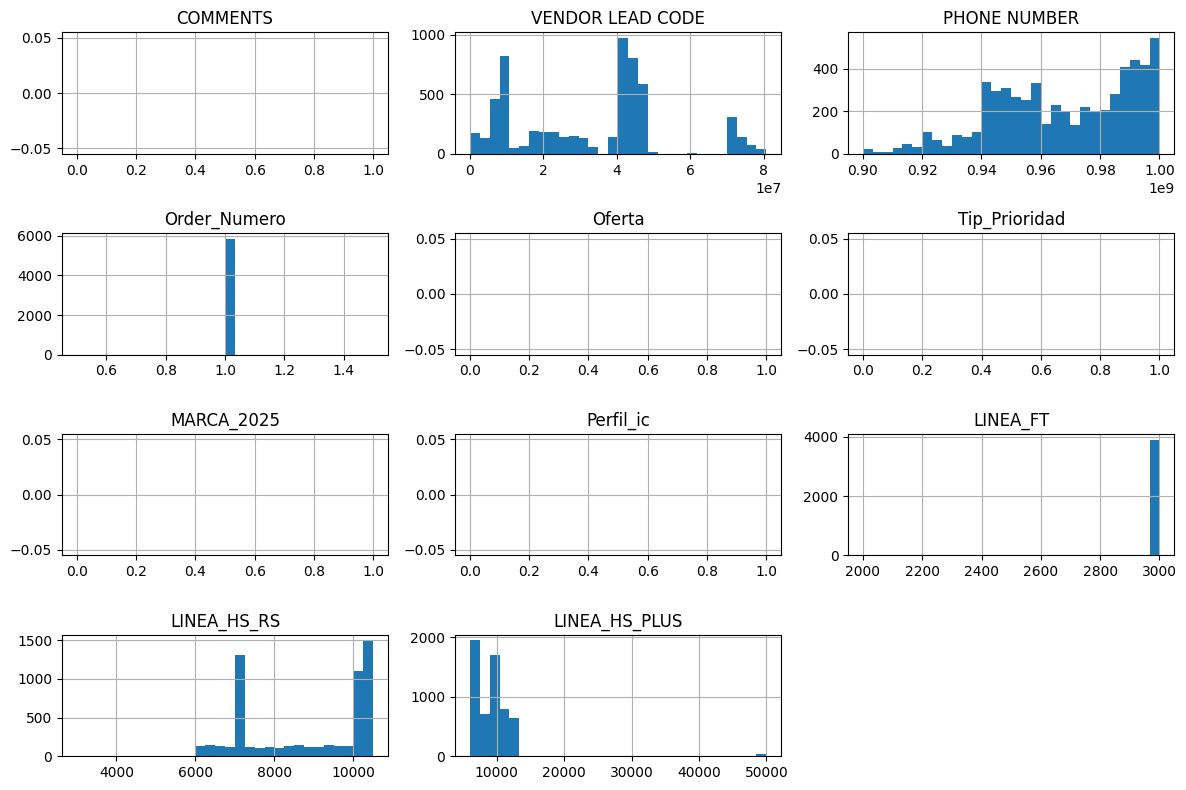

In [19]:
import numpy as np
import matplotlib.pyplot as plt

numeric_cols = df1.select_dtypes(include=np.number).columns

df1[numeric_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

In [14]:
df1.shape

(5837, 23)

In [15]:
df1.to_csv("C:\\Users\\DATA\\Documents\\datos\\01_script\\inicio\\df1.csv", index=False)

In [4]:
df_uno.describe()

,COMMENTS,VENDOR LEAD CODE,PHONE NUMBER,Order_Numero,Oferta,Tip_Prioridad,MARCA_2025,Perfil_ic,LINEA_FT,LINEA_HS_RS,LINEA_HS_PLUS
count,0.0,3.501800e+04,3.501800e+04,35018.0,0.0,0.0,0.0,0.0,23614.000000,35018.000000,35018.000000
mean,NaN,3.257255e+07,9.683459e+08,1.0,NaN,NaN,NaN,NaN,2998.687219,8788.205637,9349.642070
std,NaN,2.020312e+07,2.299886e+07,0.0,NaN,NaN,NaN,NaN,36.209290,1557.807950,3933.039001
min,NaN,1.070600e+04,9.000072e+08,1.0,NaN,NaN,NaN,NaN,2000.000000,3000.000000,6000.000000
25%,NaN,1.045454e+07,9.497392e+08,1.0,NaN,NaN,NaN,NaN,3000.000000,7000.000000,7000.000000
50%,NaN,4.039511e+07,9.699901e+08,1.0,NaN,NaN,NaN,NaN,3000.000000,9330.000000,9382.500000
75%,NaN,4.462279e+07,9.893569e+08,1.0,NaN,NaN,NaN,NaN,3000.000000,10271.000000,10425.000000
max,NaN,8.183122e+07,1.000000e+09,1.0,NaN,NaN,NaN,NaN,3000.000000,10500.000000,50000.000000


In [6]:
35018/6000


5.836333333333333

In [ ]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=tu_servidor;"
    "DATABASE=CRONOX;"
    "UID=tu_usuario;"
    "PWD=tu_password;"
)

cursor = conn.cursor()

# Ejecutar el stored procedure
cursor.execute("EXEC dbo.SP_Generador_CENCOSUD_SAE")

# Confirmar cambios (MUY IMPORTANTE)
conn.commit()

cursor.close()
conn.close()

print("Stored Procedure ejecutado correctamente")

In [70]:
query = "SELECT * FROM CRONOX.dbo.Llave_Cenco_SAE"
df_cen=get_data_sql(query, params_sa)

# query = "SELECT * FROM CRONOX.dbo.Llave_Financiera_Efe_Neg"
# df_efe_neg=get_data_sql(query, params_sa)

# query = "SELECT * FROM CRONOX.dbo.Llave_Financiera_Efe"
# df_efe_consumo=get_data_sql(query, params_sa)


In [71]:
df_cen.head()

,TITLE,FIRST NAME,LAST NAME,ADDRESS1,Address2,Address3,COMMENTS,SECURITY PHRASE,EMAIL,COMMENTS_CD,...,Mejor_Fecha_Cliente,Mejor_Duracion_Cliente,Ultimo_Descripcion_Telefono,Ultimo_Fecha_Telefono,Ultima_Duracion_Telefono,Ultimo_Descripcion_Cli,Ultimo_Fecha_Cli,Ultima_Duracion_Cli,DNI_Ejecutivo,Codigo_Paleta
0,SAE,Regimen Lab. INDEP,LIMA,CORREA LINARES CARLOS,AVENIDA PASEO DE LA REPUBLICA SAN ANTONIO 6266...,10,DEUDA_ACTUAL Sin Fecha MONTO_DESEMBOLSAR Sin M...,LINEA SAE 25000,PCT: 016 TEA: 0.099,//CONSENTIMIENTO:Y//ENTIDAD1://DEUDA1://ENTIDA...,...,2026-02-25 15:27:28,8,1.SIN GESTION,1900-01-01,0,MENSAJE EN CASILLA DE VOZ (AUTO),2026-02-27 11:43:28,0,PFC021,NaN
1,SAE,Regimen Lab. INDEP,LIMA,CORREA LINARES CARLOS,AVENIDA PASEO DE LA REPUBLICA SAN ANTONIO 6266...,10,DEUDA_ACTUAL Sin Fecha MONTO_DESEMBOLSAR Sin M...,LINEA SAE 25000,PCT: 016 TEA: 0.099,//CONSENTIMIENTO:Y//ENTIDAD1://DEUDA1://ENTIDA...,...,2026-02-25 15:27:28,8,1.SIN GESTION,1900-01-01,0,MENSAJE EN CASILLA DE VOZ (AUTO),2026-02-27 11:43:28,0,PFC021,NaN
2,SAE,Regimen Lab. INDEP,LIMA,CORREA LINARES CARLOS,AVENIDA PASEO DE LA REPUBLICA SAN ANTONIO 6266...,10,DEUDA_ACTUAL Sin Fecha MONTO_DESEMBOLSAR Sin M...,LINEA SAE 25000,PCT: 016 TEA: 0.099,//CONSENTIMIENTO:Y//ENTIDAD1://DEUDA1://ENTIDA...,...,2026-02-25 15:27:28,8,1.SIN GESTION,1900-01-01,0,MENSAJE EN CASILLA DE VOZ (AUTO),2026-02-27 11:43:28,0,PFC021,NaN
3,SAE,Regimen Lab. INDEP,LIMA,MAGUINA RODRIGUEZ DE VELASQUEZ ROSA,AVENIDA ENRIQUE MEIGGS URBANIZACION 262 URBANI...,15,DEUDA_ACTUAL Sin Fecha MONTO_DESEMBOLSAR Sin M...,LINEA SAE 1500,PCT: 035 TEA: 0.459,//CONSENTIMIENTO:Y//ENTIDAD1://DEUDA1://ENTIDA...,...,2026-02-20 11:16:14,0,1.SIN GESTION,1900-01-01,0,MENSAJE EN CASILLA DE VOZ (AUTO),2026-02-20 11:16:14,0,VDAD,NaN
4,SAE,Regimen Lab. INDEP,LIMA,MAGUINA RODRIGUEZ DE VELASQUEZ ROSA,AVENIDA ENRIQUE MEIGGS URBANIZACION 262 URBANI...,15,DEUDA_ACTUAL Sin Fecha MONTO_DESEMBOLSAR Sin M...,LINEA SAE 1500,PCT: 035 TEA: 0.459,//CONSENTIMIENTO:Y//ENTIDAD1://DEUDA1://ENTIDA...,...,2026-02-20 11:16:14,0,1.SIN GESTION,1900-01-01,0,MENSAJE EN CASILLA DE VOZ (AUTO),2026-02-20 11:16:14,0,VDAD,NaN


In [65]:
orden_01=df_efe_consumo.columns.to_list

In [57]:
df_uno=pd.read_excel("C:\\Users\\DATA\\Documents\\datos\\01_script\\inicio\\27-02 SGT.xlsx")

In [58]:
df_uno.columns = (
    df_uno.columns
    .str.strip()
    .str.upper()
    .str.replace("Á","A")
    .str.replace("É","E")
    .str.replace("Í","I")
    .str.replace("Ó","O")
    .str.replace("Ú","U")
)

In [59]:
df_uno['PHONE NUMBER'] = df_uno['NUMERO'].astype(str)


In [60]:
df_uno=df_uno[['DNI', 'NOMBRE', 'PHONE NUMBER']]

In [61]:
df_uno=df_uno.merge(df_efe_consumo, left_on='PHONE NUMBER', right_on='PHONE NUMBER', how='left')

In [ ]:
Index(['LAST NAME', 'FIRST NAME', 'ADDRESS1', 'ADDRESS3', 'COMMENTS',
       'VENDOR LEAD CODE', 'PROVINCE', 'CITY', 'EMAIL', 'COMMENTS_2',
       'PHONE NUMBER', 'Order_Numero', 'Oferta', 'Tip_Prioridad', 'MARCA_2025',
       'NOMCOMERCIAL', 'Perfil_ic', 'tipocliente', 'TIPOINGRESO', 'ASIGNACION',
       'LINEA_FT', 'LINEA_HS_RS', 'LINEA_HS_PLUS', 'LINEA_FULL', 'MARCA',
       'TIP_TELF', 'PROVEEDOR', 'PERFIL', 'SEGMENTO', 'SCORE', 'TASA',
       'RANGO_TASA', 'ZONA', 'Tipo_Telf', 'Fecha_Llam', 'Hora_Llamada',
       'FECHA_ENVIO', 'RETIRO', 'Mejor_Estado_Telefono',
       'Mejor_Sub_Estado_Telefono', 'Mejor_Descripcion_Telefono',
       'Mejor_Fecha_Telefono', 'Mejor_Hora_Telefono', 'Mejor_Durac_Telefono',
       'Mejor_Estado_Cliente', 'Mejor_Sub_Estado_Cliente',
       'Mejor_Descripcion_Cliente', 'Mejor_fecha_Cliente',
       'Mejor_Hora_Cliente', 'Mejor_Durac_Cliente', 'ULT_Descripcion_Cli',
       'ULT_fecha_Cli', 'ULT_Hora_Cli', 'ULT_Durac_Cli', 'ULT_Descripcion_Tel',
       'ULT_fecha_Tel', 'ULT_Hora_Tel', 'ULT_Durac_Tel', 'Veces_Cliente',
       'Veces_Telefono', 'REPITENCIAS', 'Cantidad_Sin_Discador',
       'Cantidad_Discador', 'TELEFO1', 'TELEFO2', 'TELEFO3', 'REGION',
       'MARCADESBASE', 'MARCA2', 'FLGSUBPROCESO_HS', 'SITUACIONLABORAL']pho

Index(['LAST NAME', 'FIRST NAME', 'ADDRESS1', 'ADDRESS3', 'COMMENTS',
       'VENDOR LEAD CODE', 'PROVINCE', 'CITY', 'EMAIL', 'COMMENTS_2',
       'PHONE NUMBER', 'Order_Numero', 'Oferta', 'Tip_Prioridad', 'MARCA_2025',
       'NOMCOMERCIAL', 'Perfil_ic', 'tipocliente', 'TIPOINGRESO', 'ASIGNACION',
       'LINEA_FT', 'LINEA_HS_RS', 'LINEA_HS_PLUS', 'LINEA_FULL', 'MARCA',
       'TIP_TELF', 'PROVEEDOR', 'PERFIL', 'SEGMENTO', 'SCORE', 'TASA',
       'RANGO_TASA', 'ZONA', 'Tipo_Telf', 'Fecha_Llam', 'Hora_Llamada',
       'FECHA_ENVIO', 'RETIRO', 'Mejor_Estado_Telefono',
       'Mejor_Sub_Estado_Telefono', 'Mejor_Descripcion_Telefono',
       'Mejor_Fecha_Telefono', 'Mejor_Hora_Telefono', 'Mejor_Durac_Telefono',
       'Mejor_Estado_Cliente', 'Mejor_Sub_Estado_Cliente',
       'Mejor_Descripcion_Cliente', 'Mejor_fecha_Cliente',
       'Mejor_Hora_Cliente', 'Mejor_Durac_Cliente', 'ULT_Descripcion_Cli',
       'ULT_fecha_Cli', 'ULT_Hora_Cli', 'ULT_Durac_Cli', 'ULT_Descripcion_Tel',
       'U

In [68]:
df_uno=df_uno[['LAST NAME', 'FIRST NAME', 'ADDRESS1', 'ADDRESS3', 'COMMENTS',
       'VENDOR LEAD CODE', 'PROVINCE', 'CITY', 'EMAIL', 'COMMENTS_2',
       'PHONE NUMBER']]

In [ ]:
df_uno

In [69]:
df_uno.to_csv("C:\\Users\\DATA\\Documents\\datos\\01_script\\inicio\\base_01.csv", index=False,sep=';')

(593162, 71)

In [ ]:
# df_efe_consumo['Mejor_Sub_Estado_Cliente'].unique()
    ['Mejor_Descripcion_Cliente'].unique()

<StringArray>
[                             'NO QUIERE',
                 'NO NECESITA / NO DESEA',
                              'SI QUIERE',
                         'ESTA ENDEUDADO',
                        'DESEA MAS MONTO',
                        'VOLVER A LLAMAR',
                                  'OTROS',
                     'CREDITO CONCRETADO',
                         'LO VA A PENSAR',
                       'CLIENTE DE VIAJE',
                     'INTERESES ELEVADOS',
        'TITULAR NO CALIFICA - DESEMPLEO',
                        'ABONO EN CUENTA',
            'CASA EN ZONA NO COBERTURADA',
                  'SOLICITA SER RETIRADO',
         'NEGOCIO EN ZONA NO COBERTURADA',
             'MALA EXPERIENCIA (TDA/FNC)',
 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9',
                         'CONFIRMAR CITA',
      'TITULAR CONTAGIADO CON COVID - 19',
                          'DESEA ELECTRO',
                      'CLIENTE RECHAZADO']
Length: 22, dtype: str

In [54]:
df_efe_consumo[df_efe_consumo['VENDOR LEAD CODE']=='47905540'].head()

,LAST NAME,FIRST NAME,ADDRESS1,ADDRESS3,COMMENTS,VENDOR LEAD CODE,PROVINCE,CITY,EMAIL,COMMENTS_2,...,Cantidad_Sin_Discador,Cantidad_Discador,TELEFO1,TELEFO2,TELEFO3,REGION,MARCADESBASE,MARCA2,FLGSUBPROCESO_HS,SITUACIONLABORAL


In [10]:
df_efe_consumo.columns

Index(['LAST NAME', 'FIRST NAME', 'ADDRESS1', 'ADDRESS3', 'COMMENTS',
       'VENDOR LEAD CODE', 'PROVINCE', 'CITY', 'EMAIL', 'COMMENTS_2',
       'PHONE NUMBER', 'Order_Numero', 'Oferta', 'Tip_Prioridad', 'MARCA_2025',
       'NOMCOMERCIAL', 'Perfil_ic', 'tipocliente', 'TIPOINGRESO', 'ASIGNACION',
       'LINEA_FT', 'LINEA_HS_RS', 'LINEA_HS_PLUS', 'LINEA_FULL', 'MARCA',
       'TIP_TELF', 'PROVEEDOR', 'PERFIL', 'SEGMENTO', 'SCORE', 'TASA',
       'RANGO_TASA', 'ZONA', 'Tipo_Telf', 'Fecha_Llam', 'Hora_Llamada',
       'FECHA_ENVIO', 'RETIRO', 'Mejor_Estado_Telefono',
       'Mejor_Sub_Estado_Telefono', 'Mejor_Descripcion_Telefono',
       'Mejor_Fecha_Telefono', 'Mejor_Hora_Telefono', 'Mejor_Durac_Telefono',
       'Mejor_Estado_Cliente', 'Mejor_Sub_Estado_Cliente',
       'Mejor_Descripcion_Cliente', 'Mejor_fecha_Cliente',
       'Mejor_Hora_Cliente', 'Mejor_Durac_Cliente', 'ULT_Descripcion_Cli',
       'ULT_fecha_Cli', 'ULT_Hora_Cli', 'ULT_Durac_Cli', 'ULT_Descripcion_Tel',
       'U

# Add list

In [115]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
# from pyspark.sql.functions import last_day, col
from dateutil.relativedelta import relativedelta

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

fecha_mes_base = '2026-03-01'

query = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.76], '
        SELECT        
        rtrim(ltrim(d.vendor_lead_code)) AS dni,        
        a.campaign_id AS Numero_Campana,        
        e.campaign_name AS Nombre_Campana,        
        a.user AS DNI_Ejecutivo,        
        c.full_name AS Ejecutivo,        
        a.call_date AS Fecha_Hora_Llamada,        
        a.length_in_sec AS segundos,        
        DATE(a.call_date) AS Fecha_Llamada,        
        HOUR(a.call_date) AS Trama_Hora,        
        '''' '''' AS Estados,        
        '''' '''' AS Sub_estado,        
        b.status_name AS Descripcion,        
        f.list_description,        
        f.list_name,        
        a.PHONE_NUMBER,        
        d.alt_phone as Fecha_Agenda,        
        d.comments as Comentarios,        
        a.status AS CODIGO,        
        FROM_UNIXTIME(a.start_epoch) as Inicio,        
        FROM_UNIXTIME(a.end_epoch) as Fin        
        FROM asterisk.vicidial_log a         
        LEFT JOIN asterisk.vicidial_list d ON a.lead_id=d.lead_id        
        LEFT JOIN asterisk.vicidial_campaigns e ON a.campaign_id=e.campaign_id        
        LEFT JOIN asterisk.vicidial_lists f ON a.list_id=f.list_id        
        LEFT JOIN asterisk.vicidial_statuses b ON a.status=b.status        
        LEFT JOIN asterisk.vicidial_users c ON a.user=c.user        
        WHERE call_date >= curdate()  and e.campaign_name like "%SAE"
    ')

    """
df_tmp_llamadas_cencosud=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [116]:
df_tmp_llamadas_cencosud.count()

22482

In [ ]:
df_tmp_llamadas_cencosud=df_tmp_llamadas_cencosud.join(df_efe_tipif_spark,["CODIGO"],"left")

window_spec = Window.partitionBy("dni","PHONE_NUMBER").orderBy(col("PESO").asc(),col("Fecha_Llamada").desc())
df_tmp_llamadas_cencosud = df_tmp_llamadas_cencosud.withColumn("mejor_Tel", row_number().over(window_spec))

window_spec = Window.partitionBy("dni").orderBy(col("PESO").asc(),col("Fecha_Llamada").desc())
df_tmp_llamadas_cencosud = df_tmp_llamadas_cencosud.withColumn("mejor_resul", row_number().over(window_spec))

window_spec = Window.partitionBy("dni",'PHONE_NUMBER').orderBy(col("Fecha_Hora_Llamada").desc())
df_tmp_llamadas_cencosud = df_tmp_llamadas_cencosud.withColumn("ult_llamada_tel", row_number().over(window_spec))

window_spec = Window.partitionBy("dni").orderBy(col("Fecha_Hora_Llamada").desc())
df_tmp_llamadas_cencosud = df_tmp_llamadas_cencosud.withColumn("ult_llamada_cli", row_number().over(window_spec))

window_count = Window.partitionBy("dni", "PHONE_NUMBER")
df_tmp_llamadas_cencosud = df_tmp_llamadas_cencosud.withColumn(
    "nCant_agent",
    count(
        when(col("DNI_Ejecutivo") != "VDAD", 1)
    ).over(window_count)
)
df_tmp_llamadas_cencosud = df_tmp_llamadas_cencosud.withColumn(
    "nCant_no_agent",
    count(
        when(col("DNI_Ejecutivo") == "VDAD", 1)
    ).over(window_count)
)
window_count = Window.partitionBy("dni")
df_tmp_llamadas_cencosud = df_tmp_llamadas_cencosud.withColumn("q_llamada_cli",count("*").over(window_count))
window_count = Window.partitionBy("dni", "PHONE_NUMBER")
df_tmp_llamadas_cencosud = df_tmp_llamadas_cencosud.withColumn("q_llamada_cli_tel",count("*").over(window_count))

# df_tmp_llamadas_cencosud = df_tmp_llamadas_cencosud.filter(col("mejor_Tel") == 1).drop('mejor_Tel')
